---

# I. DATA COLLECTION

## 1.1 What subject is your data about?

Dataset này tập trung vào **âm nhạc toàn cầu trên nền tảng Spotify**, bao gồm thông tin về:
- **Tracks (bài hát)**: Tên bài hát, độ phổ biến, nội dung tường minh
- **Artists (nghệ sĩ)**: Tên nghệ sĩ, độ phổ biến, số lượng followers, thể loại âm nhạc
- **Albums**: Thông tin về album chứa các track
- **Temporal trends**: Xu hướng âm nhạc từ 2009 đến 2025

**Real-world context:**  
Dữ liệu này đại diện cho ngành công nghiệp âm nhạc kỹ thuật số toàn cầu, bao gồm sự thay đổi về sở thích người nghe, độ phổ biến của nghệ sĩ, xu hướng thể loại nhạc, và sự chuyển đổi từ các bài hát kinh điển (2009-2023) sang các bản nhạc hiện đại (2025). Spotify là một trong những nền tảng streaming âm nhạc lớn nhất thế giới với hơn 500 triệu người dùng.

## 1.2 What is the source of your data?

**Platform:** Kaggle  
**Dataset Name:** Spotify Global Music Dataset (2009–2025)  
**URL:** https://www.kaggle.com/datasets/wardabilal/spotify-global-music-dataset-20092025/data  
**Author:** Warda Bilal  
**Publication Date:** November 2025 (last updated 20 days ago)  
**Original Source:** Spotify's Public API  

## 1.3 Is this data licensed for your use?

**License:** CC0: Public Domain  

**Educational Use:** Được phép  
Dataset này được phát hành dưới license CC0 (Public Domain), cho phép:
- Sử dụng cho mục đích giáo dục
- Sử dụng cho nghiên cứu
- Chia sẻ và phân phối

**Usage Restrictions:**  
- Không có hạn chế đặc biệt do thuộc giấy phép Public Domain
- Tác giả đã ghi rõ: "Used only for educational and research purposes" (Chỉ sử dụng cho mục đích giáo dục và nghiên cứu)
- Nên ghi nguồn: Dữ liệu được thu thập từ Spotify's public API bởi Warda Bilal trên Kaggle

## 1.4 How was this data collected?

**Collection Method:** Web scraping/API extraction
Dữ liệu được thu thập thông qua **Spotify's Public API**, một interface chính thức cho phép truy cập thông tin về tracks, artists, và albums.

**Target Population:**  
- **Đối tượng**: Các bài hát và nghệ sĩ trên Spotify
- **spotify_data clean.csv**: 8,582 bản nhạc hiện đại và nghệ sĩ gần đây (chủ yếu từ 2025)
- **track_data_final.csv**: 8,778 bản nhạc phổ biến và kinh điển từ 2009-2023 từ các nghệ sĩ nổi tiếng như Taylor Swift, Billie Eilish, Rihanna, v.v.

**Time Period:**  
- **2009-2023**: Historical data (track_data_final.csv)
- **2025**: Recent/contemporary data (spotify_data clean.csv)
Dữ liệu bao phủ từ 2009 đến năm 2025.

**Known Limitations:**
- Dữ liệu chỉ đại diện cho nền tảng Spotify, không phản ánh toàn bộ nền âm nhạc toàn cầu
- Dữ liệu phụ thuộc vào Spotify API availability
- Data các năm trước tập trung vào các nghệ sĩ nổi tiếng, có thể thiên về các nghệ sĩ phương Tây và bỏ qua các nghệ sĩ độc lập hoặc khu vực
- Độ phổ biến được đo bằng metrics của Spotify, có thể không phản ánh đầy đủ sự thành công thương mại hoặc ảnh hưởng văn hóa thực tế
- Không có dữ liệu rõ ràng cho năm 2024

## 1.5 Why did you choose this dataset?

**Group Interest:**
- Nhóm chúng em có mê với âm nhạc và công nghệ, thường xuyên nghe nhạc trên spotifty và sử dụng gói premium cho student.
- Spotify là nền tảng streaming mà tất cả thành viên trong nhóm đều sử dụng hàng ngày để giải trí
- Dataset này cung cấp cơ hội để hiểu sâu hơn về cách nền âm nhạc vận hành từ số liệu đã được cung cấp 

**Potential Questions & Insights:**
1. Làm thế nào độ phổ biến của nghệ sĩ ảnh hưởng đến độ phổ biến của tracks?
2. Các thể loại nhạc nào đang xu hướng trong những năm gần đây?
3. Có mối quan hệ nào giữa số lượng followers và track popularity?
4. Có thể dự đoán độ phổ biến của một bài hát dựa trên thông tin nghệ sĩ không?
5. Những yếu tố nào quyết định sự thành công của một nghệ sĩ?

**Practical Value:**
- Hiểu được xu hướng thị trường âm nhạc
- Hỗ trợ nghệ sĩ mới trong việc định hướng sự nghiệp
- Giúp nhà tài trợ đưa ra quyết định đầu tư
- Cải thiện recommendation systems

---

# II. DATA EXPLORATION

## 2.1 Dataset Overview

In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

# Configuration
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

In [3]:
# Load datasets
df_2025 = pd.read_csv('../dataset/spotify_data clean.csv')
df_2009_2023 = pd.read_csv('../dataset/track_data_final.csv')

print(f"Kích thước bộ dữ liệu 2025: {df_2025.shape}")
print(f"Kích thước bộ dữ liệu 2009-2023: {df_2009_2023.shape}")

Kích thước bộ dữ liệu 2025: (8582, 15)
Kích thước bộ dữ liệu 2009-2023: (8778, 15)


### Basic Information
#### Bộ dữ liệu 2025 - sportify_data_clean.csv

In [4]:
print(f"1. Số lượng dòng: {df_2025.shape[0]:,}")
print(f"2. Số lượng cột: {df_2025.shape[1]}")
print(f"3. Kích thước tổng thể: {df_2025.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print("4. Tên cột và kiểu dữ liệu:")
print(df_2025.dtypes)

1. Số lượng dòng: 8,582
2. Số lượng cột: 15
3. Kích thước tổng thể: 5.06 MB
4. Tên cột và kiểu dữ liệu:
track_id               object
track_name             object
track_number            int64
track_popularity        int64
explicit                 bool
artist_name            object
artist_popularity       int64
artist_followers        int64
artist_genres          object
album_id               object
album_name             object
album_release_date     object
album_total_tracks      int64
album_type             object
track_duration_min    float64
dtype: object


#### Bộ dữ liệu 2009 - 2023 (track_data_final.csv)

In [5]:
print(f"1. Số lượng dòng: {df_2009_2023.shape[0]:,}")
print(f"2. Số lượng cột: {df_2009_2023.shape[1]}")
print(f"3. Kích thước tổng thể: {df_2009_2023.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print("4. Tên cột và kiểu dữ liệu:")
print(df_2009_2023.dtypes)

1. Số lượng dòng: 8,778
2. Số lượng cột: 15
3. Kích thước tổng thể: 5.26 MB
4. Tên cột và kiểu dữ liệu:
track_id               object
track_name             object
track_number            int64
track_popularity        int64
track_duration_ms       int64
explicit                 bool
artist_name            object
artist_popularity     float64
artist_followers      float64
artist_genres          object
album_id               object
album_name             object
album_release_date     object
album_total_tracks      int64
album_type             object
dtype: object


### Data Integrity - Tính toàn vẹn của dữ liệu
#### Bộ dữ liệu 2025

In [6]:
# Kiểm tra trùng lặp
duplicates_by_id = df_2025[df_2025.duplicated(subset=['track_id'], keep=False)]
duplicates_first = df_2025[df_2025.duplicated(keep='first')]
completely_empty = df_2025[df_2025.isnull().all(axis=1)]

print(f"Dòng trùng lặp (theo track_id): {len(duplicates_by_id):,}")
print(f"Dòng trùng lặp (hoàn toàn): {len(duplicates_first):,}")
print(f"Dòng trống hoàn toàn: {len(completely_empty):,}")
print(f"Dòng sạch: {len(df_2025) - len(duplicates_first) - len(completely_empty):,} / {len(df_2025):,}")

if len(duplicates_first) > 0:
    print("\nMẫu các dòng trùng lặp:")
    print(duplicates_first[['track_id', 'track_name', 'artist_name']].head(3))

Dòng trùng lặp (theo track_id): 0
Dòng trùng lặp (hoàn toàn): 0
Dòng trống hoàn toàn: 0
Dòng sạch: 8,582 / 8,582


#### Bộ dữ liệu 2009 - 2023

In [7]:
# Kiểm tra trùng lặp
duplicates_by_id = df_2009_2023[df_2009_2023.duplicated(subset=['track_id'], keep=False)]
duplicates_first = df_2009_2023[df_2009_2023.duplicated(keep='first')]
completely_empty = df_2009_2023[df_2009_2023.isnull().all(axis=1)]

print(f"Dòng trùng lặp (theo track_id): {len(duplicates_by_id):,}")
print(f"Dòng trùng lặp (hoàn toàn): {len(duplicates_first):,}")
print(f"Dòng trống hoàn toàn: {len(completely_empty):,}")
print(f"Dòng sạch: {len(df_2009_2023) - len(duplicates_first) - len(completely_empty):,} / {len(df_2009_2023):,}")

if len(duplicates_first) > 0:
    print("\nMẫu các dòng trùng lặp:")
    print(duplicates_first[['track_id', 'track_name', 'artist_name']].head(3))

Dòng trùng lặp (theo track_id): 0
Dòng trùng lặp (hoàn toàn): 0
Dòng trống hoàn toàn: 0
Dòng sạch: 8,778 / 8,778


### Column Inventory

#### Bộ dữ liệu 2025

In [8]:
print("Các cột:")
for i, col in enumerate(df_2025.columns, 1):
    print(f"{i:2}. {col}")

Các cột:
 1. track_id
 2. track_name
 3. track_number
 4. track_popularity
 5. explicit
 6. artist_name
 7. artist_popularity
 8. artist_followers
 9. artist_genres
10. album_id
11. album_name
12. album_release_date
13. album_total_tracks
14. album_type
15. track_duration_min


#### Bộ dữ liệu 2009 - 2023

In [9]:
print("Các cột:")
for i, col in enumerate(df_2009_2023.columns, 1):
    print(f"{i:2}. {col}")

Các cột:
 1. track_id
 2. track_name
 3. track_number
 4. track_popularity
 5. track_duration_ms
 6. explicit
 7. artist_name
 8. artist_popularity
 9. artist_followers
10. artist_genres
11. album_id
12. album_name
13. album_release_date
14. album_total_tracks
15. album_type


### Column Definitions & Analysis

**Bảng tổng hợp các cột:**

| Column | Ý nghĩa | Relevant |
|--------|---------|----------|
| `track_id` | Mã định danh duy nhất của bài hát | $\checkmark$ |
| `track_name` | Tên bài hát | $\checkmark$ |
| `track_number` | Thứ tự bài hát trong album | $\times$ |
| `track_popularity` | Độ phổ biến (0-100) | $\checkmark$ |
| `track_duration_ms` | Thời lượng (ms) - dataset 2009-2023 | $\checkmark$ |
| `track_duration_min` | Thời lượng (phút) - dataset 2025 | $\checkmark$ |
| `explicit` | Có nội dung tường minh không | $\checkmark$ |
| `artist_name` | Tên nghệ sĩ | $\checkmark$ |
| `artist_popularity` | Độ phổ biến nghệ sĩ (0-100) | $\checkmark$ |
| `artist_followers` | Số lượng người theo dõi nghệ sĩ | $\checkmark$ |
| `artist_genres` | Thể loại nhạc | $\checkmark$ |
| `album_id` | Mã định danh album | $\times$ |
| `album_name` | Tên album | $\times$ |
| `album_release_date` | Ngày phát hành | $\checkmark$ |
| `album_total_tracks` | Tổng số bài trong album | ? |
| `album_type` | Loại phát hành (album/single/compilation) | ? |

---

**Columns cần thiết:**

**1. Thông tin định danh:**
- **`track_id`**: Cần thiết để xác định duy nhất từng bài hát, loại bỏ duplicate, và join datasets
- **`track_name`**: Giúp hiểu được bài hát nào đang phân tích, có thể dùng cho text analysis sau này
- **`artist_name`**: Quan trọng để nhóm dữ liệu theo nghệ sĩ, phân tích nghệ sĩ nào thành công nhất

**2. Chỉ số độ phổ biến:**
- **`track_popularity`**: Đây là target variable chính - thước đo mức độ thành công của bài hát
- **`artist_popularity`**: Nghệ sĩ nổi tiếng thường ra bài hit dễ hơn, đây là predictor mạnh
- **`artist_followers`**: Số lượng fan base - có tương quan cao với khả năng bài hát viral

**3. Đặc điểm âm nhạc:**
- **`track_duration_ms` / `track_duration_min`**: Xu hướng hiện nay thiên về bài ngắn (2-3 phút). Có thể phân tích: bài ngắn hay dài được ưa chuộng hơn?
- **`explicit`**: Nội dung tường minh đang là xu hướng trong một số thể loại (rap, hip-hop). Đáng để phân tích trend theo thời gian
- **`artist_genres`**: Rất quan trọng - cho phép phân tích thể loại nào đang hot (pop, EDM, hip-hop...), dự đoán popularity theo genre

**4. Thông tin thời gian:**
- **`album_release_date`**: Cho phép time series analysis - xu hướng âm nhạc thay đổi như thế nào qua các năm? Có seasonal pattern không?

---

**Columns nên xóa:**

**1. `track_number`** - Thứ tự trong album
- Người nghe streaming ít quan tâm bài số mấy trong album
- Không ảnh hưởng đến độ phổ biến (bởi vì sẽ không có ai nói "tôi chỉ nghe bài số 3")

**2. `album_id`** - Mã định danh album  
- Chỉ hữu ích nếu phân tích theo album (không phải mục tiêu chính)
- Đã có `album_name` và `album_release_date` để tham chiếu nếu cần

**3. `album_name`** - Tên album
- Ít giá trị phân tích vì người nghe thời đại streaming ít quan tâm album
- Xu hướng là họ nghe từng bài riêng lẻ hoặc playlist, không nghe cả album

---

**Columns cần cân nhắc (tùy hướng phân tích):**

**1. `album_total_tracks`** - Số lượng bài trong album
- **Giữ nếu**: Muốn phân tích single vs album - single có marketing tập trung hơn nên có thể phổ biến hơn?
- **Xóa nếu**: Không nghiên cứu về chiến lược phát hành
- **Đề xuất**: Giữ lại tạm, vì có thể tạo feature mới: `is_single = (album_total_tracks == 1)`

**2. `album_type`** - Loại phát hành
- **Giữ nếu**: Muốn so sánh single vs album vs compilation
- **Xóa nếu**: Chỉ tập trung vào đặc điểm bài hát
- **Đề xuất**: Giữ lại vì có 3 giá trị duy nhất, dễ phân tích, có thể cho insight về chiến lược marketing

---

**Sự khác biệt giữa 2 datasets:**

- **Duration khác đơn vị**: Cần convert về cùng đơn vị (nên covert về phút)
- **Missing values**: Dataset 2025 thiếu `artist_genres` nhiều (39%) 
- **Data types**: Cần standardize `artist_popularity` và `artist_followers` về cùng kiểu khi merge

### Data Types Analysis

#### Bộ dữ liệu 2025

In [10]:
print("Kiểu dữ liệu hiện tại của mỗi cột:")
for col in df_2025.columns:
    print(f"{col:25}: {df_2025[col].dtype}")

Kiểu dữ liệu hiện tại của mỗi cột:
track_id                 : object
track_name               : object
track_number             : int64
track_popularity         : int64
explicit                 : bool
artist_name              : object
artist_popularity        : int64
artist_followers         : int64
artist_genres            : object
album_id                 : object
album_name               : object
album_release_date       : object
album_total_tracks       : int64
album_type               : object
track_duration_min       : float64


#### Bộ dữ liệu 2009-2023

In [11]:
print("Kiểu dữ liệu hiện tại của mỗi cột:")
for col in df_2009_2023.columns:
    print(f"{col:25}: {df_2009_2023[col].dtype}")

Kiểu dữ liệu hiện tại của mỗi cột:
track_id                 : object
track_name               : object
track_number             : int64
track_popularity         : int64
track_duration_ms        : int64
explicit                 : bool
artist_name              : object
artist_popularity        : float64
artist_followers         : float64
artist_genres            : object
album_id                 : object
album_name               : object
album_release_date       : object
album_total_tracks       : int64
album_type               : object


### Inappropriate Data Types

1. **`artist_popularity` và `artist_followers`** - Không nhất quán giữa 2 datasets
   - Dataset 2025: `int64` 
   - Dataset 2009-2023: `float64` 
   - **Cần sửa**: Convert về `int64` cho cả 2 datasets

2. **`track_duration_ms` vs `track_duration_min`** - Khác đơn vị
   - Dataset 2025: `track_duration_min` (phút, float64)
   - Dataset 2009-2023: `track_duration_ms` (milliseconds, int64)
   - **Cần sửa**: Standardize về cùng đơn vị (phút)

In [12]:
# Dataset 2025: Convert artist_popularity and artist_followers to int64
df_2025['artist_popularity'] = df_2025['artist_popularity'].fillna(0).astype('int64')
df_2025['artist_followers'] = df_2025['artist_followers'].fillna(0).astype('int64')
# Dataset 2009-2023: Convert artist_popularity and artist_followers to int64
df_2009_2023['artist_popularity'] = df_2009_2023['artist_popularity'].fillna(0).astype('int64')
df_2009_2023['artist_followers'] = df_2009_2023['artist_followers'].fillna(0).astype('int64')
# Dataset 2009-2023: Convert track_duration_ms to track_duration_min (float64)
df_2009_2023['track_duration_min'] = df_2009_2023['track_duration_ms'] / 60000.0
df_2009_2023 = df_2009_2023.drop(columns=['track_duration_ms']) 

## 2.2 Numerical Columns Analysis

In [13]:
# Xác định các cột số
numerical_cols_2025 = df_2025.select_dtypes(include=['int64', 'float64']).columns.tolist()
numerical_cols_2009 = df_2009_2023.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("Bộ dữ liệu 2025 - các cột số:")
for i, col in enumerate(numerical_cols_2025, 1):
    print(f"{i}. {col}")

print("\nBộ dữ liệu 2009-2023 - các cột số:")
for i, col in enumerate(numerical_cols_2009, 1):
    print(f"{i}. {col}")

Bộ dữ liệu 2025 - các cột số:
1. track_number
2. track_popularity
3. artist_popularity
4. artist_followers
5. album_total_tracks
6. track_duration_min

Bộ dữ liệu 2009-2023 - các cột số:
1. track_number
2. track_popularity
3. artist_popularity
4. artist_followers
5. album_total_tracks
6. track_duration_min


### Distribution & Central Tendency

**Mục đích:** Hiểu numerical columns phân bố như thế nào

In [14]:
# Tính mean, median, std cho mỗi dataset
print(f"{'Cột':<25} {'Bộ dữ liệu 2025':^45} {'Bộ dữ liệu 2009-2023':^45}")
print(f"{'':25} {'Trung bình':>15} {'Trung vị':>15} {'Độ lệch chuẩn':>15} | {'Trung bình':>15} {'Trung vị':>15} {'Độ lệch chuẩn':>15}")

for col in sorted(numerical_cols_2025):
    # Dataset 2025
    mean_2025 = df_2025[col].mean()
    median_2025 = df_2025[col].median()
    std_2025 = df_2025[col].std()
    
    # Dataset 2009-2023
    if col in df_2009_2023.columns:
        mean_2009 = df_2009_2023[col].mean()
        median_2009 = df_2009_2023[col].median()
        std_2009 = df_2009_2023[col].std()
    else:
        mean_2009, median_2009, std_2009 = 0, 0, 0
    
    print(f"{col:<25} {mean_2025:>15.2f} {median_2025:>15.2f} {std_2025:>15.2f} |{mean_2009:>15.2f} {median_2009:>15.2f} {std_2009:>15.2f}")

Cột                                      Bộ dữ liệu 2025                            Bộ dữ liệu 2009-2023             
                               Trung bình        Trung vị   Độ lệch chuẩn |      Trung bình        Trung vị   Độ lệch chuẩn
album_total_tracks                  13.79           13.00           11.89 |          13.78           13.00           11.80
artist_followers              24034719.33      6105547.00     38031804.96 |    24343767.66      6223889.50     38132537.98
artist_popularity                   69.73           74.00           19.65 |          69.92           74.00           19.59
track_duration_min                   3.49            3.45            1.06 |           3.50            3.45            1.06
track_number                         5.77            4.00            6.05 |           5.75            4.00            6.02
track_popularity                    52.36           58.00           23.82 |          52.23           58.00           24.08


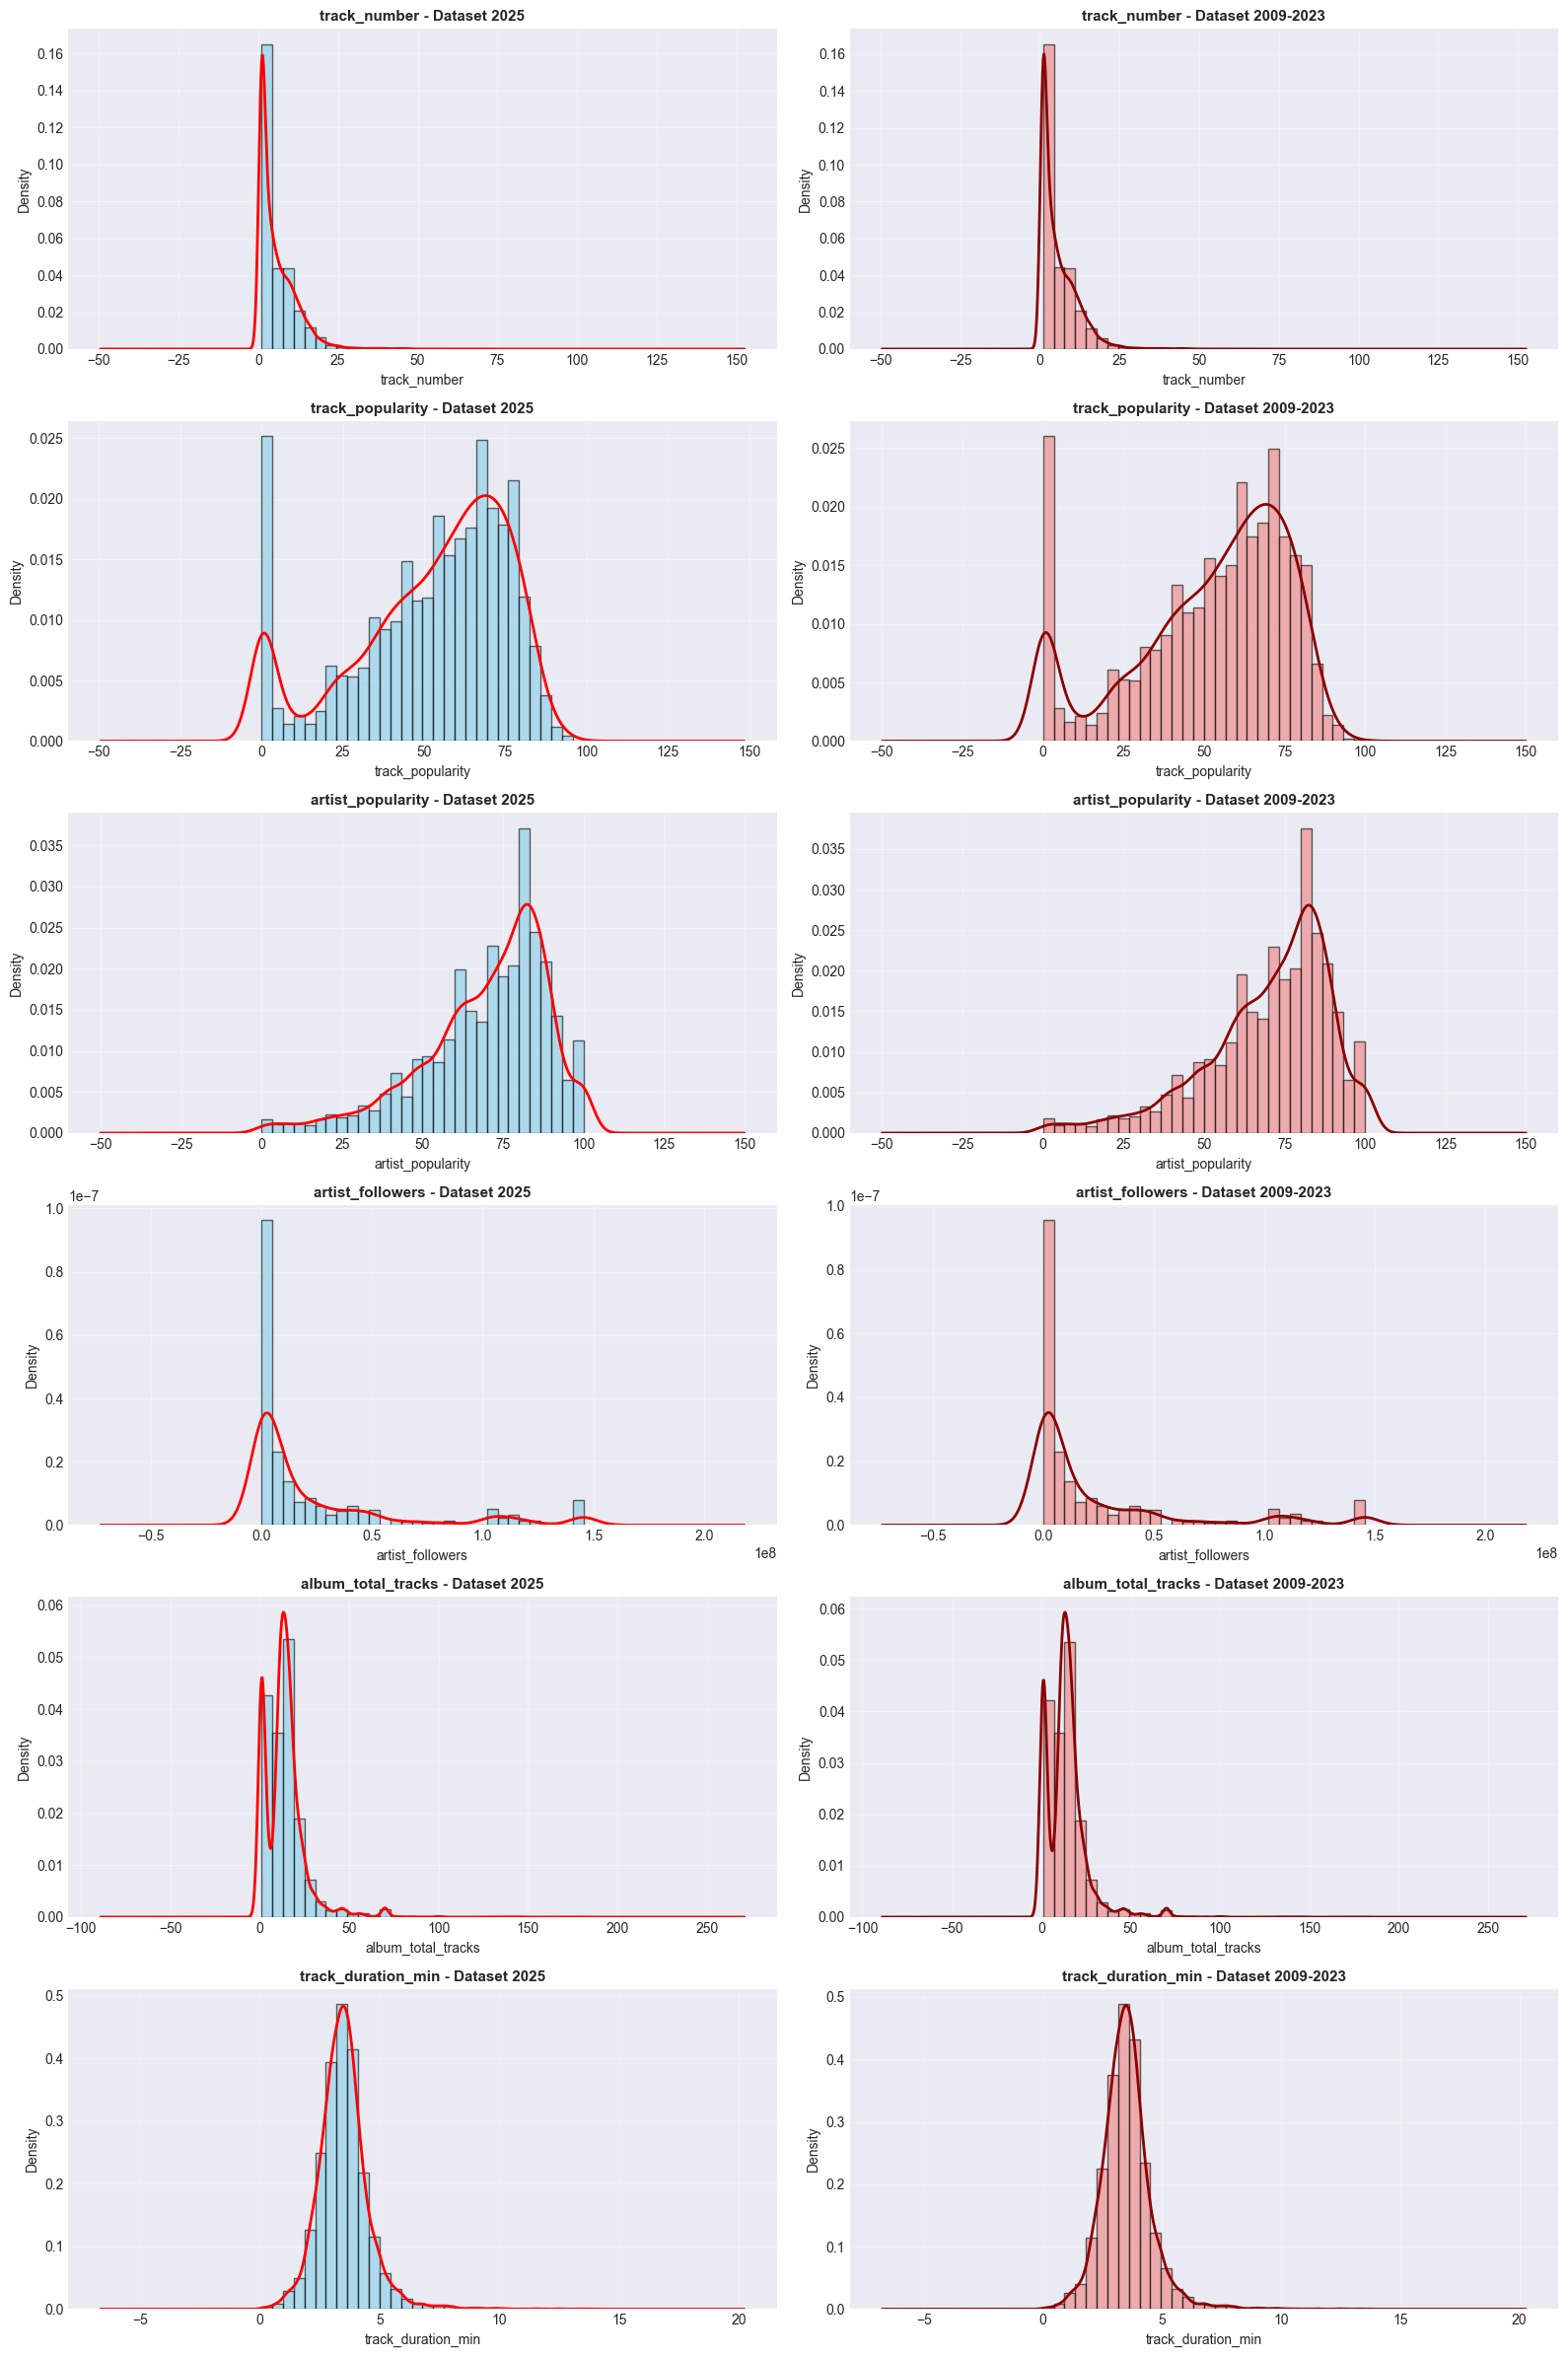

In [15]:
# Trực quan hóa phân phối cho mỗi cột số với biểu đồ histogram và đường KDE
fig, axes = plt.subplots(len(numerical_cols_2025), 2, figsize=(16, 4*len(numerical_cols_2025)))

for i, col in enumerate(numerical_cols_2025):
    # Dataset 2025
    data_2025 = df_2025[col].dropna()
    axes[i, 0].hist(data_2025, bins=30, edgecolor='black', alpha=0.6, density=True, color='skyblue')
    data_2025.plot(kind='kde', ax=axes[i, 0], color='red', linewidth=2)
    axes[i, 0].set_title(f'{col} - Dataset 2025', fontsize=11, fontweight='bold')
    axes[i, 0].set_xlabel(col, fontsize=10)
    axes[i, 0].set_ylabel('Density', fontsize=10)
    axes[i, 0].grid(alpha=0.3)
    
    # Dataset 2009-2023
    if col in numerical_cols_2009 or col == 'track_duration_min':
        data_2009 = df_2009_2023[col].dropna()
        axes[i, 1].hist(data_2009, bins=30, edgecolor='black', alpha=0.6, density=True, color='lightcoral')
        data_2009.plot(kind='kde', ax=axes[i, 1], color='darkred', linewidth=2)
        axes[i, 1].set_title(f'{col} - Dataset 2009-2023', fontsize=11, fontweight='bold')
        axes[i, 1].set_xlabel(col, fontsize=10)
        axes[i, 1].set_ylabel('Density', fontsize=10)
        axes[i, 1].grid(alpha=0.3)
    else:
        axes[i, 1].text(0.5, 0.5, 'Column not available\nin 2009-2023 dataset', 
                       ha='center', va='center', fontsize=12)
        axes[i, 1].set_title(f'{col} - Dataset 2009-2023 (N/A)', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

In [16]:
# Xác định hình dạng phân phối của các đặc trưng số
from scipy import stats

print(f"\n{'Cột':<25} {'Bộ dữ liệu 2025':^45} {'Bộ dữ liệu 2009-2023':^45}")
print(f"{'':25} {'Độ lệch':>10} {'Độ nhọn':>10} {'Hình dạng':<25} | {'Độ lệch':>10} {'Độ nhọn':>10} {'Hình dạng':<25}")

for col in sorted(numerical_cols_2025):
    # Dataset 2025
    data_2025 = df_2025[col].dropna()
    skew_2025 = stats.skew(data_2025)
    kurt_2025 = stats.kurtosis(data_2025)
    
    if abs(skew_2025) < 0.5 and abs(kurt_2025) < 1:
        shape_2025 = "chuẩn"
    elif skew_2025 > 1:
        shape_2025 = "lệch phải"
    elif skew_2025 < -1:
        shape_2025 = "lệch trái"
    elif abs(kurt_2025) > 3:
        shape_2025 = "đuôi nặng"
    elif abs(kurt_2025) < -1:
        shape_2025 = "đồng đều"
    else:
        shape_2025 = "lệch vừa phải"
    
    # Dataset 2009-2023
    if col in df_2009_2023.columns:
        data_2009 = df_2009_2023[col].dropna()
        skew_2009 = stats.skew(data_2009)
        kurt_2009 = stats.kurtosis(data_2009)
        
        if abs(skew_2009) < 0.5 and abs(kurt_2009) < 1:
            shape_2009 = "chuẩn"
        elif skew_2009 > 1:
            shape_2009 = "lệch phải"
        elif skew_2009 < -1:
            shape_2009 = "lệch trái"
        elif abs(kurt_2009) > 3:
            shape_2009 = "đuôi nặng"
        elif abs(kurt_2009) < -1:
            shape_2009 = "đồng đều"
        else:
            shape_2009 = "lệch vừa phải"
    else:
        skew_2009, kurt_2009, shape_2009 = 0, 0, "N/A"
    
    print(f"{col:<25} {skew_2025:>10.3f} {kurt_2025:>10.3f} {shape_2025:<25} | {skew_2009:>10.3f} {kurt_2009:>10.3f} {shape_2009:<25}")


Cột                                      Bộ dữ liệu 2025                            Bộ dữ liệu 2009-2023             
                             Độ lệch    Độ nhọn Hình dạng                 |    Độ lệch    Độ nhọn Hình dạng                
album_total_tracks             2.872     18.456 lệch phải                 |      2.874     18.637 lệch phải                
artist_followers               1.961      2.852 lệch phải                 |      1.932      2.738 lệch phải                
artist_popularity             -1.039      1.025 lệch trái                 |     -1.060      1.094 lệch trái                
track_duration_min             1.284      7.041 lệch phải                 |      1.265      6.990 lệch phải                
track_number                   2.653     16.498 lệch phải                 |      2.656     16.571 lệch phải                
track_popularity              -0.785     -0.238 lệch vừa phải             |     -0.779     -0.279 lệch vừa phải            


### Range & Outliers

**Mục đích:** Tìm giá trị bất thường và kiểm tra tính hợp lý

In [17]:
# Kiểm tra giá trị min/max của các cột số - so sánh hai bộ dữ liệu
print(f"{'Cột':<25} {'Bộ dữ liệu 2025':^45} {'Bộ dữ liệu 2009-2023':^45}")
print(f"{'':25} {'Min':>15} {'Max':>15} {'Khoảng':>15} | {'Min':>15} {'Max':>15} {'Khoảng':>15}")

for col in sorted(numerical_cols_2025):
    # Dataset 2025
    min_2025 = df_2025[col].min()
    max_2025 = df_2025[col].max()
    range_2025 = max_2025 - min_2025
    
    # Dataset 2009-2023
    if col in df_2009_2023.columns:
        min_2009 = df_2009_2023[col].min()
        max_2009 = df_2009_2023[col].max()
        range_2009 = max_2009 - min_2009
    else:
        min_2009, max_2009, range_2009 = 0, 0, 0
    
    print(f"{col:<25} {min_2025:>15.2f} {max_2025:>15.2f} {range_2025:>15.2f} | {min_2009:>15.2f} {max_2009:>15.2f} {range_2009:>15.2f}")

Cột                                      Bộ dữ liệu 2025                            Bộ dữ liệu 2009-2023             
                                      Min             Max          Khoảng |             Min             Max          Khoảng
album_total_tracks                   1.00          181.00          180.00 |            1.00          181.00          180.00
artist_followers                     0.00    145542136.00    145542136.00 |            0.00    145542136.00    145542136.00
artist_popularity                    0.00          100.00          100.00 |            0.00          100.00          100.00
track_duration_min                   0.07           13.51           13.44 |            0.00           13.52           13.52
track_number                         1.00          102.00          101.00 |            1.00          102.00          101.00
track_popularity                     0.00           99.00           99.00 |            0.00          100.00          100.00


**Phân tích Min/Max values:**

**Giá trị hợp lý:**
- `track_popularity`, `artist_popularity`: Nằm trong khoảng 0-100 (hợp lý theo định nghĩa của Spotify)
- `track_number`: Min = 1 là hợp lý (bài đầu tiên trong album)
- `album_total_tracks`: Min = 1 là hợp lý (album/single có ít nhất 1 bài)

**Giá trị cần kiểm tra:**
- `artist_followers`: Max lớn do có thể là nghệ sĩ nổi tiếng (Taylor Swift, BTS, etc.)
- `track_duration_min` / `track_duration_ms`: Max lớn do có thể là bài hát dài hoặc lỗi dữ liệu
- `track_number`, `album_total_tracks`: Max lớn nên cần kiểm tra xem có phải compilation album hay không

**Điểm bất thường:**
- Nếu `track_popularity` hoặc `artist_popularity` = 0 do Có thể là bài/nghệ sĩ mới hoặc không phổ biến
- Nếu `artist_followers` = 0 do có thể là lỗi dữ liệu hoặc nghệ sĩ không có followers

In [18]:
# So sánh percentile và phát hiện ngoại lai - so sánh hai bộ dữ liệu
from scipy import stats as sp_stats

print(f"{'Cột':<25} {'Bộ dữ liệu 2025':^55} {'Bộ dữ liệu 2009-2023':^55}")
print(f"{'':25} {'Q1':>10} {'Q3':>10} {'IQR':>10} {'Dưới':>10} {'Trên':>10} {'Ngoại lai':>10} | {'Q1':>10} {'Q3':>10} {'IQR':>10} {'Dưới':>10} {'Trên':>10} {'Ngoại lai':>10}")

for col in sorted(numerical_cols_2025):
    # Dataset 2025
    q1_2025 = df_2025[col].quantile(0.25)
    q3_2025 = df_2025[col].quantile(0.75)
    iqr_2025 = q3_2025 - q1_2025
    lower_2025 = q1_2025 - 1.5 * iqr_2025
    upper_2025 = q3_2025 + 1.5 * iqr_2025
    outliers_2025 = ((df_2025[col] < lower_2025) | (df_2025[col] > upper_2025)).sum()
    non_null_2025 = df_2025[col].notna().sum()
    outlier_pct_2025 = (outliers_2025 / non_null_2025) * 100 if non_null_2025 > 0 else 0
    
    # Dataset 2009-2023
    if col in df_2009_2023.columns:
        q1_2009 = df_2009_2023[col].quantile(0.25)
        q3_2009 = df_2009_2023[col].quantile(0.75)
        iqr_2009 = q3_2009 - q1_2009
        lower_2009 = q1_2009 - 1.5 * iqr_2009
        upper_2009 = q3_2009 + 1.5 * iqr_2009
        outliers_2009 = ((df_2009_2023[col] < lower_2009) | (df_2009_2023[col] > upper_2009)).sum()
        non_null_2009 = df_2009_2023[col].notna().sum()
        outlier_pct_2009 = (outliers_2009 / non_null_2009) * 100 if non_null_2009 > 0 else 0
    else:
        q1_2009, q3_2009, iqr_2009, lower_2009, upper_2009, outliers_2009, outlier_pct_2009 = 0, 0, 0, 0, 0, 0, 0
    
    print(f"{col:<25} {q1_2025:>10.1f} {q3_2025:>10.1f} {iqr_2025:>10.1f} {lower_2025:>10.1f} {upper_2025:>10.1f} {outliers_2025:>7}({outlier_pct_2025:>4.1f}%) | {q1_2009:>10.1f} {q3_2009:>10.1f} {iqr_2009:>10.1f} {lower_2009:>10.1f} {upper_2009:>10.1f} {outliers_2009:>7}({outlier_pct_2009:>4.1f}%)")

Cột                                           Bộ dữ liệu 2025                                      Bộ dữ liệu 2009-2023                  
                                  Q1         Q3        IQR       Dưới       Trên  Ngoại lai |         Q1         Q3        IQR       Dưới       Trên  Ngoại lai
album_total_tracks               6.0       17.0       11.0      -10.5       33.5     379( 4.4%) |        6.0       17.0       11.0      -10.5       33.5     380( 4.3%)
artist_followers            462320.0 27252551.0 26790231.0 -39723026.5 67437897.5    1044(12.2%) |   512702.5 30550549.0 30037846.5 -44544067.2 75607318.8     999(11.4%)
artist_popularity               60.0       84.0       24.0       24.0      120.0     286( 3.3%) |       60.0       84.0       24.0       24.0      120.0     289( 3.3%)
track_duration_min               2.9        4.0        1.1        1.2        5.7     358( 4.2%) |        2.9        4.0        1.1        1.3        5.6     377( 4.3%)
track_number                

**Phân tích Outliers:**

**IQR Method Interpretation:**
- **Lower Bound** = Q1 - 1.5 $\times$ IQR
- **Upper Bound** = Q3 + 1.5 $\times$ IQR
- Giá trị nào nằm ngoài khoảng [Lower, Upper] thì là outliers

**Outliers có thể là giá trị hợp lý:**
- `artist_followers`: Nghệ sĩ siêu nổi tiếng (Taylor Swift, BTS, The Weeknd) có số followers rất cao
- `track_duration_min/ms`: Một số bài hát thực sự dài (classical, progressive rock, live recordings)
- `album_total_tracks`: Compilation album, box sets có thể có rất nhiều tracks

**Outliers có thể là lỗi dữ liệu:**
- `track_number` hoặc `album_total_tracks` quá cao (> 100) 
- `track_popularity` hoặc `artist_popularity` = 0 liên tục 
- `track_duration` quá ngắn (< 30s) hoặc quá dài (> 30 phút)

**Cần cân nhắc:**
- Columns có tỷ lệ outliers > 10% cần recheck
- Xem xét kỹ từng context của outlier (tên bài, nghệ sĩ, album) để đưa ra quyết định

### Data Quality Check

**Mục đích:** Kiểm tra chất lượng dữ liệu số

In [19]:
# Tính phần trăm giá trị thiếu cho mỗi cột số - so sánh hai bộ dữ liệu
print(f"{'Cột':<25} {'Bộ dữ liệu 2025':^30} {'Bộ dữ liệu 2009-2023':^30}")
print(f"{'':25} {'Thiếu':>15} {'Phần trăm':>15} | {'Thiếu':>15} {'Phần trăm':>15}")

for col in sorted(numerical_cols_2025):
    # Dataset 2025
    missing_2025 = df_2025[col].isnull().sum()
    pct_2025 = (missing_2025 / len(df_2025)) * 100
    
    # Dataset 2009-2023
    if col in df_2009_2023.columns:
        missing_2009 = df_2009_2023[col].isnull().sum()
        pct_2009 = (missing_2009 / len(df_2009_2023)) * 100
    else:
        missing_2009, pct_2009 = 0, 0
    
    print(f"{col:<25} {missing_2025:>15,} {pct_2025:>14.2f}% | {missing_2009:>15,} {pct_2009:>14.2f}%")

Cột                              Bộ dữ liệu 2025              Bộ dữ liệu 2009-2023     
                                    Thiếu       Phần trăm |           Thiếu       Phần trăm
album_total_tracks                      0           0.00% |               0           0.00%
artist_followers                        0           0.00% |               0           0.00%
artist_popularity                       0           0.00% |               0           0.00%
track_duration_min                      0           0.00% |               0           0.00%
track_number                            0           0.00% |               0           0.00%
track_popularity                        0           0.00% |               0           0.00%


**Phân tích Placeholder Values:**

**1. Giá trị 0 (Zero Values):**

**Hợp lý:**
- `track_popularity` = 0: Bài hát mới phát hành hoặc chưa được nghe nhiều → Giữ lại
- `artist_popularity` = 0: Nghệ sĩ mới, chưa có fan base → Giữ lại
- `artist_followers` = 0: Nghệ sĩ mới hoặc independent artist chưa có người theo dõi → Giữ lại (nhưng cần kiểm tra thêm)

**Không hợp lý (cần xử lý):**
- `track_number` = 0: Album luôn bắt đầu từ track 1, 0 là lỗi → Convert sang NaN hoặc 1
- `album_total_tracks` = 0: Album không thể có 0 bài, đây là lỗi → Convert sang NaN hoặc 1 (nếu là single)
- `track_duration_min` = 0: Bài hát không thể dài 0 phút → Đây là missing value, convert sang NaN

**Nghi ngờ (cần investigate):**
- Nếu `artist_followers` = 0 nhưng `artist_popularity` > 50 → Không logic, có thể là lỗi
- Nếu cả `track_popularity` và `artist_popularity` đều = 0 đồng thời → Nghi ngờ là placeholder

---

**2. Giá trị -1 (Negative One):**

**Pattern nhận biết:**
- Giá trị -1 thường được dùng trong database để đánh dấu "unknown" hoặc "not applicable"
- Không có column numerical nào trong dataset Spotify hợp lý với giá trị âm

**Quyết định:**
- Nếu xuất hiện -1 ở bất kỳ column nào thì là placeholder cho missing value
- Convert tất cả -1 thành NaN
- Xử lý như missing data

---

**3. Giá trị 999 (Sentinel Value):**

**Pattern nhận biết:**
- 999 thường được dùng làm "magic number" để đánh dấu missing value
- Đặc biệt nghi ngờ ở các column có giới hạn tự nhiên như `track_number`, `album_total_tracks`

**Hành động:**
- `track_number` = 999: Rất khó có album 999 tracks cho nên ta convert sang NaN
- `album_total_tracks` = 999: Compilation album lớn nhất cũng không quá 100 tracks nên cần phải check
- Nếu 999 xuất hiện nhiều lần ở cùng 1 column thì đó là placeholder

In [20]:
# Kiểm tra giá trị placeholder (0, -1, 999, etc.)
print(f"{'Cột':<25} {'Bộ dữ liệu 2025':^45} {'Bộ dữ liệu 2009-2023':^45}")
print(f"{'':25} {'Số 0':>15} {'(-1)':>15} {'(999)':>15} {'Số 0':>15} {'(-1)':>15} {'(999)':>15}")

for col in sorted(numerical_cols_2025):
    # Dataset 2025
    zeros_2025 = (df_2025[col] == 0).sum()
    negones_2025 = (df_2025[col] == -1).sum()
    nines_2025 = (df_2025[col] == 999).sum()
    
    # Dataset 2009-2023
    if col in df_2009_2023.columns:
        zeros_2009 = (df_2009_2023[col] == 0).sum()
        negones_2009 = (df_2009_2023[col] == -1).sum()
        nines_2009 = (df_2009_2023[col] == 999).sum()
    else:
        zeros_2009, negones_2009, nines_2009 = 0, 0, 0
    
    print(f"{col:<25} {zeros_2025:>15,} {negones_2025:>15,} {nines_2025:>15,} {zeros_2009:>15,} {negones_2009:>15,} {nines_2009:>15,}")

Cột                                      Bộ dữ liệu 2025                            Bộ dữ liệu 2009-2023             
                                     Số 0            (-1)           (999)            Số 0            (-1)           (999)
album_total_tracks                      0               0               0               0               0               0
artist_followers                        8               0               0               9               0               0
artist_popularity                      25               0               0              28               0               0
track_duration_min                      0               0               0               2               0               0
track_number                            0               0               0               0               0               0
track_popularity                      503               0               0             521               0               0


**Phân tích Impossible Values:**

**Giá trị không hợp lệ cần kiểm tra:**
- `track_popularity`, `artist_popularity`: Phải nằm trong [0, 100]
- `artist_followers`, `album_total_tracks`, `track_number`: Không được âm
- `track_duration_min`: Phải > 0, hợp lý nằm trong [0.5, 30] phút

**Hành động:**
- Nếu có giá trị âm hoặc vượt quá giới hạn thì là lỗi dữ liệu, cần xử lý
- Giá trị 0 có thể hợp lý (bài/nghệ sĩ chưa phổ biến)
- Giá trị ngoài khoảng hợp lý cần kiểm tra lại

In [21]:
# Kiểm tra giá trị ngoài khoảng hợp lệ trong các cột số
print("Giá trị ngoài khoảng [0, 100]:")
for col in ['track_popularity', 'artist_popularity']:
    invalid_2025 = df_2025[(df_2025[col] < 0) | (df_2025[col] > 100)][col].count()
    invalid_2009 = df_2009_2023[(df_2009_2023[col] < 0) | (df_2009_2023[col] > 100)][col].count()
    print(f"{col}: {invalid_2025:,} (2025), {invalid_2009:,} (2009-2023)")

print("\nGiá trị âm:")
for col in ['artist_followers', 'album_total_tracks', 'track_number']:
    negative_2025 = df_2025[df_2025[col] < 0][col].count()
    if col in df_2009_2023.columns:
        negative_2009 = df_2009_2023[df_2009_2023[col] < 0][col].count()
        print(f"{col}: {negative_2025:,} (2025), {negative_2009:,} (2009-2023)")
    else:
        print(f"{col}: {negative_2025:,} (2025)")

print("\nVấn đề về thời lượng:")
col = 'track_duration_min'
zero_2025 = df_2025[df_2025[col] <= 0][col].count()
unreasonable_2025 = df_2025[(df_2025[col] > 0) & ((df_2025[col] < 0.5) | (df_2025[col] > 30))][col].count()
zero_2009 = df_2009_2023[df_2009_2023[col] <= 0][col].count()
unreasonable_2009 = df_2009_2023[(df_2009_2023[col] > 0) & ((df_2009_2023[col] < 0.5) | (df_2009_2023[col] > 30))][col].count()
print(f"Thời lượng bằng 0/âm: {zero_2025:,} (2025), {zero_2009:,} (2009-2023)")
print(f"Thời lượng không hợp lý (<0.5 phút hoặc >30 phút): {unreasonable_2025:,} (2025), {unreasonable_2009:,} (2009-2023)")

Giá trị ngoài khoảng [0, 100]:
track_popularity: 0 (2025), 0 (2009-2023)
artist_popularity: 0 (2025), 0 (2009-2023)

Giá trị âm:
artist_followers: 0 (2025), 0 (2009-2023)
album_total_tracks: 0 (2025), 0 (2009-2023)
track_number: 0 (2025), 0 (2009-2023)

Vấn đề về thời lượng:
Thời lượng bằng 0/âm: 0 (2025), 2 (2009-2023)
Thời lượng không hợp lý (<0.5 phút hoặc >30 phút): 11 (2025), 11 (2009-2023)


**Phân tích Missing Values:**
- Columns nào có missing values nhiều nhất cần được xử lý
- Nếu missing > 30% thì cần cân nhắc loại bỏ hoặc imputation cẩn thận
- So sánh tỷ lệ missing giữa 2 datasets

## 2.3 Categorical Columns Analysis

**Mục đích:** Phân tích các cột phân loại

In [22]:
# Xác định các cột phân loại
categorical_cols_2025 = df_2025.select_dtypes(include=['object']).columns.tolist()
categorical_cols_2009 = df_2009_2023.select_dtypes(include=['object']).columns.tolist()

print("Bộ dữ liệu 2025 - các cột phân loại:")
for i, col in enumerate(categorical_cols_2025, 1):
    print(f"{i}. {col}")

print("\nBộ dữ liệu 2009-2023 - các cột phân loại:")
for i, col in enumerate(categorical_cols_2009, 1):
    print(f"{i}. {col}")

Bộ dữ liệu 2025 - các cột phân loại:
1. track_id
2. track_name
3. artist_name
4. artist_genres
5. album_id
6. album_name
7. album_release_date
8. album_type

Bộ dữ liệu 2009-2023 - các cột phân loại:
1. track_id
2. track_name
3. artist_name
4. artist_genres
5. album_id
6. album_name
7. album_release_date
8. album_type


### Value Distribution

**Mục đích:** Phân tích phân bố giá trị của từng categorical column

#### Phân bố giá trị của bộ dữ liệu 2025 

In [23]:
# Đếm các giá trị unique và tần suất của chúng trong mỗi cột phân loại - so sánh hai bộ dữ liệu
all_top_values = {}
for col in categorical_cols_2025:
    top_10 = df_2025[col].value_counts().head(10)
    all_top_values[col] = top_10

# In đầu dòng
col_width = 35
header = f"{'Hạng':<6}"
for col in categorical_cols_2025:
    header += f"{col[:30]:<{col_width}}"
print(header)
print(f"{'Duy nhất:':<6}", end='')
for col in categorical_cols_2025:
    print(f"{df_2025[col].nunique():,} giá trị{'':<{col_width-len(str(df_2025[col].nunique()))-9}}", end='')
print("\n")

# In 10 dòng đầu tiên
for rank in range(10):
    print(f"#{rank+1:<5}", end='')
    for col in categorical_cols_2025:
        if rank < len(all_top_values[col]):
            value = list(all_top_values[col].index)[rank]
            count = all_top_values[col].iloc[rank]
            percentage = (count / len(df_2025)) * 100
            
            # Truncate long values
            display_value = str(value)[:20] + "..." if len(str(value)) > 20 else str(value)
            cell_content = f"{display_value} ({count:,}, {percentage:.1f}%)"
            
            # Truncate if still too long
            if len(cell_content) > col_width - 1:
                cell_content = cell_content[:col_width-4] + "..."
            
            print(f"{cell_content:<{col_width}}", end='')
        else:
            print(f"{'-':<{col_width}}", end='')
    print()

Hạng  track_id                           track_name                         artist_name                        artist_genres                      album_id                           album_name                         album_release_date                 album_type                         
Duy nhất:8,582 giá trị                      7,462 giá trị                      2,547 giá trị                      661 giá trị                       5,205 giá trị                      4,870 giá trị                      2,384 giá trị                      3 giá trị                         

#1    3EJS5LyekDim1Tf5rBFm... (1, 0.0%)  Home (8, 0.1%)                     Taylor Swift (324, 3.8%)           soundtrack (345, 4.0%)             3FFGbUutKWN1c4f0CJR4... (70, 0.8%) Nevermind (Super Del... (70, 0.8%) 2010-01-01 (76, 0.9%)              album (5,856, 68.2%)               
#2    5XIROml6NGQvRdDiEQ7H... (1, 0.0%)  Flowers (8, 0.1%)                  The Weeknd (141, 1.6%)             pop (326, 3.8%)           

#### Phân bố giá trị của bộ dữ liệu 2009-2023

In [24]:
all_top_values = {}
for col in categorical_cols_2009:
    top_10 = df_2009_2023[col].value_counts().head(10)
    all_top_values[col] = top_10

# In đầu dòng
col_width = 35
header = f"{'hạng':<6}"
for col in categorical_cols_2009:
    header += f"{col[:30]:<{col_width}}"
print(header)
print(f"{'duy nhất:':<6}", end='')
for col in categorical_cols_2009:
    print(f"{df_2009_2023[col].nunique():,} giá trị{'':<{col_width-len(str(df_2009_2023[col].nunique()))-9}}", end='')
print("\n")

# In 10 dòng đầu tiên
for rank in range(10):
    print(f"#{rank+1:<5}", end='')
    for col in categorical_cols_2009:
        if rank < len(all_top_values[col]):
            value = list(all_top_values[col].index)[rank]
            count = all_top_values[col].iloc[rank]
            percentage = (count / len(df_2009_2023)) * 100
            
            display_value = str(value)[:20] + "..." if len(str(value)) > 20 else str(value)
            cell_content = f"{display_value} ({count:,}, {percentage:.1f}%)"
            
            if len(cell_content) > col_width - 1:
                cell_content = cell_content[:col_width-4] + "..."
            
            print(f"{cell_content:<{col_width}}", end='')
        else:
            print(f"{'-':<{col_width}}", end='')
    print()

hạng  track_id                           track_name                         artist_name                        artist_genres                      album_id                           album_name                         album_release_date                 album_type                         
duy nhất:8,778 giá trị                      7,465 giá trị                      2,548 giá trị                      652 giá trị                       5,317 giá trị                      4,873 giá trị                      2,390 giá trị                      3 giá trị                         

#1    6pymOcrCnMuCWdgGVTvU... (1, 0.0%)  Flowers (8, 0.1%)                  Taylor Swift (330, 3.8%)           [] (4,492, 51.2%)                  3FFGbUutKWN1c4f0CJR4... (70, 0.8%) Nevermind (Super Del... (70, 0.8%) 2010-01-01 (78, 0.9%)              album (6,022, 68.6%)               
#2    7BMO7O7ImjV8HNTH74Ts... (1, 0.0%)  Ghost (8, 0.1%)                    The Weeknd (151, 1.7%)             ['soundtrack'] (346, 3.9%)

**Đánh giá về phần sẽ visualization:**

Các columns như `track_id`, `track_name`, `artist_name`, `album_id`, `album_name`, `artist_genres`, `album_release_date` có **quá nhiều unique values** (hàng nghìn giá trị) nên không phù hợp để visualize.

Chỉ visualize 2 columns có số lượng categories hợp lý:
- `explicit`: True/False (2 values)
- `album_type`: album/single/compilation (3 values)

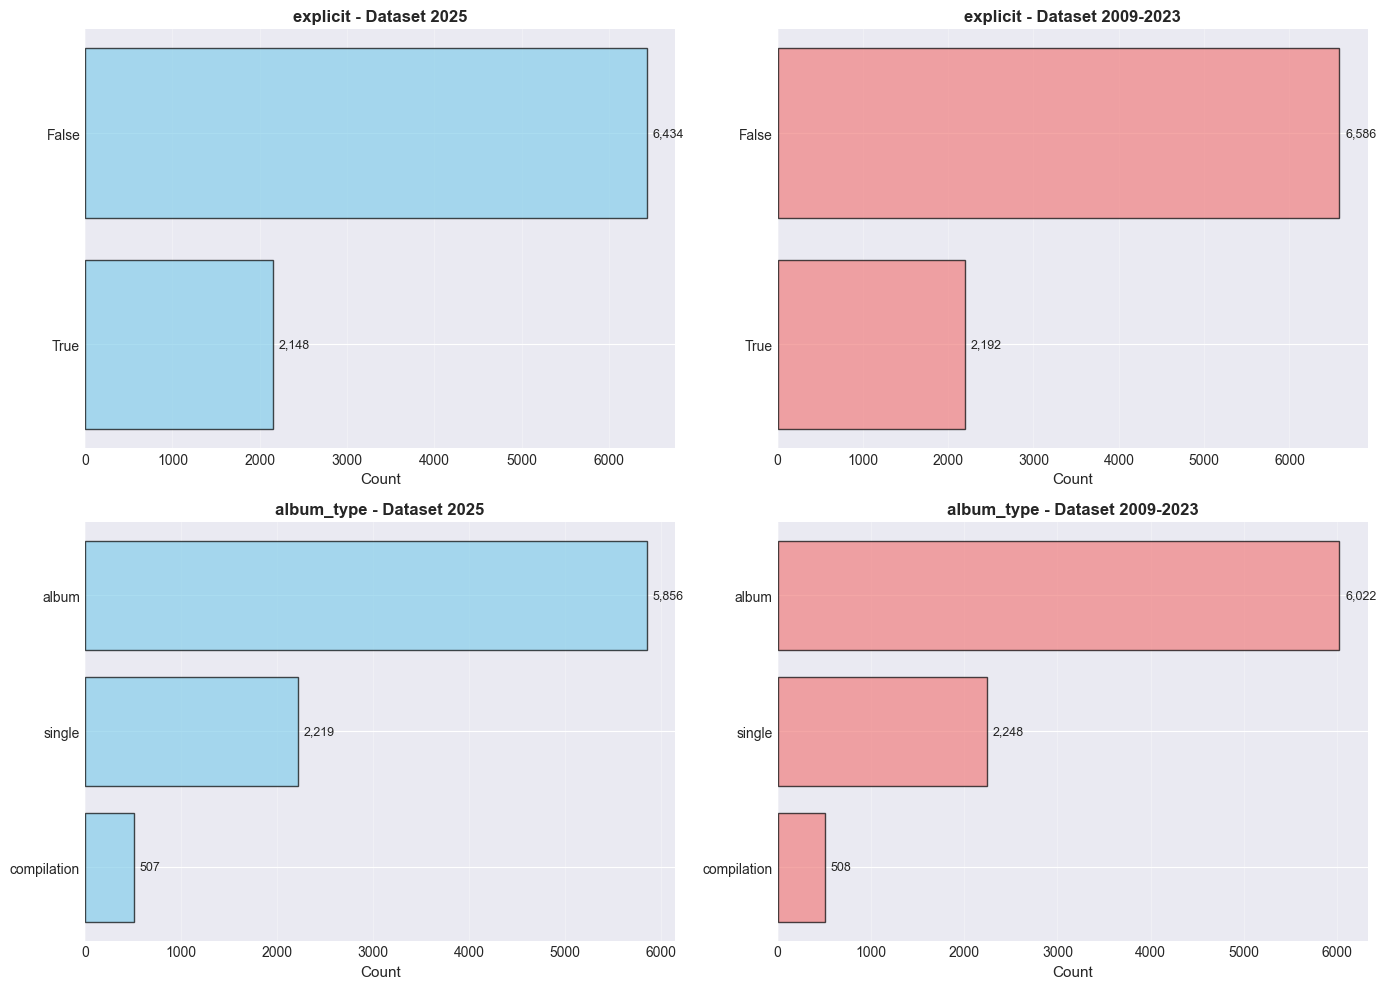

In [25]:
# Trực quan hóa các giá trị phân loại phổ biến nhất trong mỗi cột phân loại - so sánh hai bộ dữ liệu
import matplotlib.pyplot as plt

# Tập trung vào các cột phân loại với số lượng giá trị unique thấp
viz_cols = ['explicit', 'album_type']  

fig, axes = plt.subplots(len(viz_cols), 2, figsize=(14, 5*len(viz_cols)))

if len(viz_cols) == 1:
    axes = axes.reshape(1, -1)

for i, col in enumerate(viz_cols):
    # Dataset 2025
    if col in df_2025.columns:
        top_values_2025 = df_2025[col].value_counts().head(10)
        axes[i, 0].barh(range(len(top_values_2025)), top_values_2025.values, color='skyblue', edgecolor='black', alpha=0.7)
        axes[i, 0].set_yticks(range(len(top_values_2025)))
        axes[i, 0].set_yticklabels(top_values_2025.index, fontsize=10)
        axes[i, 0].set_xlabel('Count', fontsize=11)
        axes[i, 0].set_title(f'{col} - Dataset 2025', fontsize=12, fontweight='bold')
        axes[i, 0].grid(alpha=0.3, axis='x')
        axes[i, 0].invert_yaxis()  
        
        # Thêm nhãn đếm
        for j, v in enumerate(top_values_2025.values):
            axes[i, 0].text(v + max(top_values_2025.values)*0.01, j, f'{v:,}', va='center', fontsize=9)
    
    # Dataset 2009-2023
    if col in df_2009_2023.columns:
        top_values_2009 = df_2009_2023[col].value_counts().head(10)
        axes[i, 1].barh(range(len(top_values_2009)), top_values_2009.values, color='lightcoral', edgecolor='black', alpha=0.7)
        axes[i, 1].set_yticks(range(len(top_values_2009)))
        axes[i, 1].set_yticklabels(top_values_2009.index, fontsize=10)
        axes[i, 1].set_xlabel('Count', fontsize=11)
        axes[i, 1].set_title(f'{col} - Dataset 2009-2023', fontsize=12, fontweight='bold')
        axes[i, 1].grid(alpha=0.3, axis='x')
        axes[i, 1].invert_yaxis()  
        # Thêm nhãn đếm
        for j, v in enumerate(top_values_2009.values):
            axes[i, 1].text(v + max(top_values_2009.values)*0.01, j, f'{v:,}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

### Distribution Balance Analysis

**Mục đích:** Đánh giá mức độ cân bằng của từng categorical column

**1. Balanced Categories:**

**`explicit`:**
- Dataset 2025: False (6,434 - 75.0%), True (2,148 - 25.0%)
- Dataset 2009-2023: False (6,586 - 75.0%), True (2,192 - 25.0%)
- **Kết luận**: Tương đối cân bằng ở cả 2 datasets, tỷ lệ 3:1 (False:True)

**`album_type`:**
- Dataset 2025: album (5,856 - 68.2%), single (2,219 - 25.9%), compilation (507 - 5.9%)
- Dataset 2009-2023: album (6,022 - 68.6%), single (2,248 - 25.6%), compilation (508 - 5.8%)
- **Kết luận**: Cân bằng vừa phải, album chiếm đa số nhưng không quá áp đảo, tỷ lệ tương tự nhau giữa 2 datasets, không cần xử lý imbalance

**2. Imbalanced Categories:**

**Highly Fragmented (phân mảnh cao):**
- **`track_id`**: primary key, không dùng phân tích
- **`track_name`**: 7,462 unique, top value 8 lần, có thể có duplicates
- **`album_id`**, **`album_name`: top value 70 lần (0.8%)
- **`album_release_date`**: 2,384 unique, top value 76 lần

$\rightarrow$ Đề xuất: Group theo năm hoặc tháng để phân tích xu hướng theo thời gian

**Moderately Concentrated (tập trung vừa phải):**
- **`artist_name`**: 2,547 unique, Taylor Swift (3.8%), The Weeknd (1.6%)

$\rightarrow$ Đề xuất: Có thể group các nghệ sĩ ít bài hát thành nhóm "Others"
- **`artist_genres`**: 
  - Dataset 2025: 661 unique, "soundtrack" (4.0%), "pop" (3.8%)
  - Dataset 2009-2023: 652 unique, **51.2% missing values**

$\rightarrow$ Đề xuất: Cần xử lý missing values trước khi sử dụng cho modeling

### Data Quality Check

**Mục đích:** Kiểm tra chất lượng dữ liệu categorical

In [26]:
# Phần trăm giá trị thiếu cho mỗi cột phân loại - so sánh hai bộ dữ liệu
print("Giá trị thiếu - các cột phân loại\n")
print(f"{'Cột':<25} {'Bộ dữ liệu 2025':^30} {'Bộ dữ liệu 2009-2023':^30}")
print(f"{'':25} {'Thiếu':>15} {'Phần trăm':>15} | {'Thiếu':>15} {'Phần trăm':>15}")

for col in categorical_cols_2025:
    # Dataset 2025
    missing_2025 = df_2025[col].isnull().sum()
    pct_2025 = (missing_2025 / len(df_2025)) * 100
    
    # Dataset 2009-2023
    if col in df_2009_2023.columns:
        missing_2009 = df_2009_2023[col].isnull().sum()
        pct_2009 = (missing_2009 / len(df_2009_2023)) * 100
    else:
        missing_2009, pct_2009 = 0, 0
    
    print(f"{col:<25} {missing_2025:>15,} {pct_2025:>14.2f}% | {missing_2009:>15,} {pct_2009:>14.2f}%")

Giá trị thiếu - các cột phân loại

Cột                              Bộ dữ liệu 2025              Bộ dữ liệu 2009-2023     
                                    Thiếu       Phần trăm |           Thiếu       Phần trăm
track_id                                0           0.00% |               0           0.00%
track_name                              0           0.00% |               2           0.02%
artist_name                             3           0.03% |               4           0.05%
artist_genres                       3,361          39.16% |               4           0.05%
album_id                                0           0.00% |               0           0.00%
album_name                              0           0.00% |               2           0.02%
album_release_date                      0           0.00% |               0           0.00%
album_type                              0           0.00% |               0           0.00%


#### Kiểm tra sự không nhất quán ở các cột phân loại của hai bộ dữ liệu

In [27]:
# Kiểm tra sự không nhất quán trong các cột phân loại (biến thể chữ hoa/thường, khoảng trắng)
clean_cols = []
issue_cols = []

for col in categorical_cols_2025:
    # Dataset 2025 - Kiểm tra biến thể chữ hoa/thường và khoảng trắng
    unique_values_2025 = df_2025[col].dropna().unique()
    lower_map_2025 = {}
    for val in unique_values_2025:
        val_str = str(val)
        lower_val = val_str.lower().strip()
        if lower_val not in lower_map_2025:
            lower_map_2025[lower_val] = []
        lower_map_2025[lower_val].append(val_str)
    
    case_issues_2025 = {k: v for k, v in lower_map_2025.items() if len(v) > 1}
    
    # Dataset 2009-2023 - Kiểm tra biến thể chữ hoa/thường và khoảng trắng
    case_issues_2009 = {}
    if col in df_2009_2023.columns:
        unique_values_2009 = df_2009_2023[col].dropna().unique()
        lower_map_2009 = {}
        for val in unique_values_2009:
            val_str = str(val)
            lower_val = val_str.lower().strip()
            if lower_val not in lower_map_2009:
                lower_map_2009[lower_val] = []
            lower_map_2009[lower_val].append(val_str)
        
        case_issues_2009 = {k: v for k, v in lower_map_2009.items() if len(v) > 1}
    
    # Categorize columns
    if not case_issues_2025 and not case_issues_2009:
        clean_cols.append(col)
    else:
        issue_cols.append({
            'col': col,
            'issues_2025': case_issues_2025,
            'issues_2009': case_issues_2009
        })

print("Các cột sạch (không phát hiện biến thể chữ hoa/thường):")
for col in clean_cols:
    print(f"{col}")

# In các cột có sự không nhất quán
print("\nCác cột có sự không nhất quán:")

for item in issue_cols:
    col = item['col']
    case_issues_2025 = item['issues_2025']
    case_issues_2009 = item['issues_2009']
    
    print(f"\n{col}:")
    
    if case_issues_2025:
        print(f"Bộ dữ liệu 2025: {len(case_issues_2025)} biến thể")
        for lower_val, variations in list(case_issues_2025.items())[:3]:
            var_str = ', '.join([f"'{v}'" for v in variations[:4]])
            print(f"->{var_str}")
    
    if case_issues_2009:
        print(f"Bộ dữ liệu 2009-2023: {len(case_issues_2009)} biến thể")
        for lower_val, variations in list(case_issues_2009.items())[:3]:
            var_str = ', '.join([f"'{v}'" for v in variations[:4]])
            print(f"->{var_str}")

Các cột sạch (không phát hiện biến thể chữ hoa/thường):
track_id
artist_name
artist_genres
album_id
album_release_date
album_type

Các cột có sự không nhất quán:

track_name:
Bộ dữ liệu 2025: 109 biến thể
->'BLEED', 'Bleed'
->'superstar', 'SuperStar'
->'Part of Me', 'Part Of Me'
Bộ dữ liệu 2009-2023: 110 biến thể
->'blue', 'Blue', 'BLUE'
->'Pretty Please', 'PRETTY PLEASE'
->'DADDY', 'Daddy'

album_name:
Bộ dữ liệu 2025: 41 biến thể
->'BLEED', 'Bleed'
->'LEGENDARY', 'Legendary'
->'Golden Hour', 'golden hour'
Bộ dữ liệu 2009-2023: 42 biến thể
->'I Put a Spell on You', 'I Put A Spell On You'
->'blue', 'Blue'
->'Positions', 'positions'


#### Kiểm tra các giá trị bất thường

In [28]:
# Kiểm tra các giá trị bất thường trong các cột phân loại - so sánh hai bộ dữ liệu
print(f"{'Cột':<25} {'Bộ dữ liệu 2025':^50} {'Bộ dữ liệu 2009-2023':^50}")
print("-" * 125)

for col in categorical_cols_2025:
    unique_2025 = df_2025[col].dropna().unique()
    if len(unique_2025) <= 5:
        display_2025 = str(list(unique_2025))
    else:
        display_2025 = f"{len(unique_2025):,} giá trị duy nhất (top 3: {list(unique_2025[:3])})"
    
    if col in df_2009_2023.columns:
        unique_2009 = df_2009_2023[col].dropna().unique()
        if len(unique_2009) <= 5:
            display_2009 = str(list(unique_2009))
        else:
            display_2009 = f"{len(unique_2009):,} giá trị duy nhất (top 3: {list(unique_2009[:3])})"
    else:
        display_2009 = "N/A"
    
    print(f"{col:<25} {display_2025[:48]:<50} {display_2009[:48]:<50}")

# Kiểm tra chuỗi rỗng hoặc khoảng trắng
print("\n\nKiểm tra giá trị trống/ khoảng trắng:")

has_empty = False
for col in categorical_cols_2025:
    empty_2025 = df_2025[col].apply(lambda x: str(x).strip() == '' if pd.notna(x) else False).sum()
    
    if col in df_2009_2023.columns:
        empty_2009 = df_2009_2023[col].apply(lambda x: str(x).strip() == '' if pd.notna(x) else False).sum()
    else:
        empty_2009 = 0
    
    if empty_2025 > 0 or empty_2009 > 0:
        has_empty = True
        print(f"  {col}: {empty_2025:,} (2025), {empty_2009:,} (2009-2023)")

if not has_empty:
    print("Không tìm thấy giá trị trống hoặc chỉ có khoảng trắng trong bất kỳ cột nào")

Cột                                        Bộ dữ liệu 2025                                  Bộ dữ liệu 2009-2023               
-----------------------------------------------------------------------------------------------------------------------------
track_id                  8,582 giá trị duy nhất (top 3: ['3EJS5LyekDim1Tf   8,778 giá trị duy nhất (top 3: ['6pymOcrCnMuCWdg  
track_name                7,462 giá trị duy nhất (top 3: ['Trippy Mane (ft   7,465 giá trị duy nhất (top 3: ['3', 'Clouds', '  
artist_name               2,547 giá trị duy nhất (top 3: ['Diplo', 'Yelawo   2,548 giá trị duy nhất (top 3: ['Britney Spears'  
artist_genres             661 giá trị duy nhất (top 3: ['moombahton', 'cou   652 giá trị duy nhất (top 3: ["['pop']", "['stut  
album_id                  5,205 giá trị duy nhất (top 3: ['5QRFnGnBeMGePBK   5,317 giá trị duy nhất (top 3: ['325wcm5wMnlfjmK  
album_name                4,870 giá trị duy nhất (top 3: ['d00mscrvll, Vol   4,873 giá trị duy nhất (top 3

#### Xác định các phân loại hiếm gặp

In [29]:
print("các phân loại hiếm gặp (< 1% tổng số)\n")

for col in categorical_cols_2025:
    print(f"{col}:")
    
    # Dataset 2025
    value_counts_2025 = df_2025[col].value_counts()
    total_2025 = len(df_2025)
    rare_2025 = value_counts_2025[value_counts_2025 / total_2025 < 0.01]
    
    print(f"Bộ dữ liệu 2025: {len(rare_2025):,} phân loại hiếm (trong tổng số {value_counts_2025.shape[0]:,} giá trị duy nhất)")
    if len(rare_2025) > 0 and len(rare_2025) <= 10:
        print(f"Ví dụ: {list(rare_2025.head(5).index)}")
    
    # Dataset 2009-2023
    if col in df_2009_2023.columns:
        value_counts_2009 = df_2009_2023[col].value_counts()
        total_2009 = len(df_2009_2023)
        rare_2009 = value_counts_2009[value_counts_2009 / total_2009 < 0.01]
        
        print(f"Bộ dữ liệu 2009-2023: {len(rare_2009):,} phân loại hiếm (trong tổng số {value_counts_2009.shape[0]:,} giá trị duy nhất)")
        if len(rare_2009) > 0 and len(rare_2009) <= 10:
            print(f"Ví dụ: {list(rare_2009.head(5).index)}")
    
    print()

các phân loại hiếm gặp (< 1% tổng số)

track_id:
Bộ dữ liệu 2025: 8,582 phân loại hiếm (trong tổng số 8,582 giá trị duy nhất)
Bộ dữ liệu 2009-2023: 8,778 phân loại hiếm (trong tổng số 8,778 giá trị duy nhất)

track_name:
Bộ dữ liệu 2025: 7,462 phân loại hiếm (trong tổng số 7,462 giá trị duy nhất)
Bộ dữ liệu 2009-2023: 7,465 phân loại hiếm (trong tổng số 7,465 giá trị duy nhất)

artist_name:
Bộ dữ liệu 2025: 2,542 phân loại hiếm (trong tổng số 2,547 giá trị duy nhất)
Bộ dữ liệu 2009-2023: 2,543 phân loại hiếm (trong tổng số 2,548 giá trị duy nhất)

artist_genres:
Bộ dữ liệu 2025: 650 phân loại hiếm (trong tổng số 661 giá trị duy nhất)
Bộ dữ liệu 2009-2023: 643 phân loại hiếm (trong tổng số 652 giá trị duy nhất)

album_id:
Bộ dữ liệu 2025: 5,205 phân loại hiếm (trong tổng số 5,205 giá trị duy nhất)
Bộ dữ liệu 2009-2023: 5,317 phân loại hiếm (trong tổng số 5,317 giá trị duy nhất)

album_name:
Bộ dữ liệu 2025: 4,870 phân loại hiếm (trong tổng số 4,870 giá trị duy nhất)
Bộ dữ liệu 2009-2023

**Có nên gộp rare categories?**

** Các categories không nên gộp:**
- **`track_id`, `album_id`**: Primary keys, cần giữ nguyên
- **`artist_name`, `track_name`, `album_name`**: Identifiers quan trọng, không gộp
- **`album_release_date`**: Thời gian, nên group theo year/quarter thay vì gộp thành "Other"

**Các categoires có thể gộp:**
- **`artist_genres`**: Có thể nhóm các thể loại hiếm (<1%) vào "Other genres" hoặc group theo genre lớn hơn

## 2.4 Missing Data Analysis

**Mục đích:** Phân tích dữ liệu thiếu và patterns

### Overall Missing Values Summary

**Mục đích:** Tổng quan về missing values trong tất cả columns

In [30]:
# Missing values summary
missing_summary_2025 = pd.DataFrame({
    'Column': df_2025.columns,
    'Missing_Count': df_2025.isnull().sum(),
    'Total_Rows': len(df_2025),
    'Missing_Percent': (df_2025.isnull().sum() / len(df_2025) * 100).round(2)
}).sort_values('Missing_Percent', ascending=False)

missing_summary_2009 = pd.DataFrame({
    'Column': df_2009_2023.columns,
    'Missing_Count': df_2009_2023.isnull().sum(),
    'Total_Rows': len(df_2009_2023),
    'Missing_Percent': (df_2009_2023.isnull().sum() / len(df_2009_2023) * 100).round(2)
}).sort_values('Missing_Percent', ascending=False)

# Dataset 2025 - Missing values summary
print("="*80)
print("Tổng hợp các giá trị thiếu trong bộ dữ liệu 2025")
print("="*80)
print(f"{'Cột':<28} {'Thiếu':>12} {'Tổng':>12} {'Phần trăm':>12}   {'Trạng thái':<12}")
print("-"*80)
for _, row in missing_summary_2025.iterrows():
    status = "[Thiếu dữ liệu]" if row['Missing_Percent'] > 0 else "[Đầy đủ]"
    print(f"{row['Column']:<28} {row['Missing_Count']:>12,.0f} {row['Total_Rows']:>12,} {row['Missing_Percent']:>11.2f}%   {status:<12}")

# Dataset 2009-2023 - Missing values summary
print("\n" + "="*80)
print("Tổng hợp các giá trị thiếu trong bộ dữ liệu 2009-2023")
print("="*80)
print(f"{'Cột':<28} {'Thiếu':>12} {'Tổng':>12} {'Phần trăm':>12}   {'Trạng thái':<12}")
print("-"*80)
for _, row in missing_summary_2009.iterrows():
    status = "[Thiếu dữ liệu]" if row['Missing_Percent'] > 0 else "[Đầy đủ]"
    print(f"{row['Column']:<28} {row['Missing_Count']:>12,.0f} {row['Total_Rows']:>12,} {row['Missing_Percent']:>11.2f}%   {status:<12}")

# Overall statistics
print("\n" + "="*80)
print("Thống kê tổng quan")
print("="*80)

total_cells_2025 = df_2025.shape[0] * df_2025.shape[1]
total_missing_2025 = df_2025.isnull().sum().sum()
print("\nBộ dữ liệu 2025:")
print(f"- Tổng số ô:               {total_cells_2025:>12,}")
print(f"- Số ô thiếu:              {total_missing_2025:>12,}")
print(f"- Phần trăm thiếu:         {(total_missing_2025/total_cells_2025*100):>11.2f}%")
print(f"- Số cột có giá trị thiếu: {(missing_summary_2025['Missing_Count'] > 0).sum():>12,}")

total_cells_2009 = df_2009_2023.shape[0] * df_2009_2023.shape[1]
total_missing_2009 = df_2009_2023.isnull().sum().sum()
print("\nBộ dữ liệu 2009-2023:")
print(f"- Tổng số ô:               {total_cells_2009:>12,}")
print(f"- Số ô thiếu:              {total_missing_2009:>12,}")
print(f"- Phần trăm thiếu:         {(total_missing_2009/total_cells_2009*100):>11.2f}%")
print(f"- Số cột có giá trị thiếu: {(missing_summary_2009['Missing_Count'] > 0).sum():>12,}")
print("="*80)

Tổng hợp các giá trị thiếu trong bộ dữ liệu 2025
Cột                                 Thiếu         Tổng    Phần trăm   Trạng thái  
--------------------------------------------------------------------------------
artist_genres                       3,361        8,582       39.16%   [Thiếu dữ liệu]
artist_name                             3        8,582        0.03%   [Thiếu dữ liệu]
track_id                                0        8,582        0.00%   [Đầy đủ]    
track_name                              0        8,582        0.00%   [Đầy đủ]    
track_number                            0        8,582        0.00%   [Đầy đủ]    
track_popularity                        0        8,582        0.00%   [Đầy đủ]    
explicit                                0        8,582        0.00%   [Đầy đủ]    
artist_popularity                       0        8,582        0.00%   [Đầy đủ]    
artist_followers                        0        8,582        0.00%   [Đầy đủ]    
album_id                          

### Missing Data Visualization

**Mục đích:** Visualize missing patterns với heatmap và bar chart

BIỂU ĐỒ CỘT - PHẦN TRĂM GIÁ TRỊ THIẾU


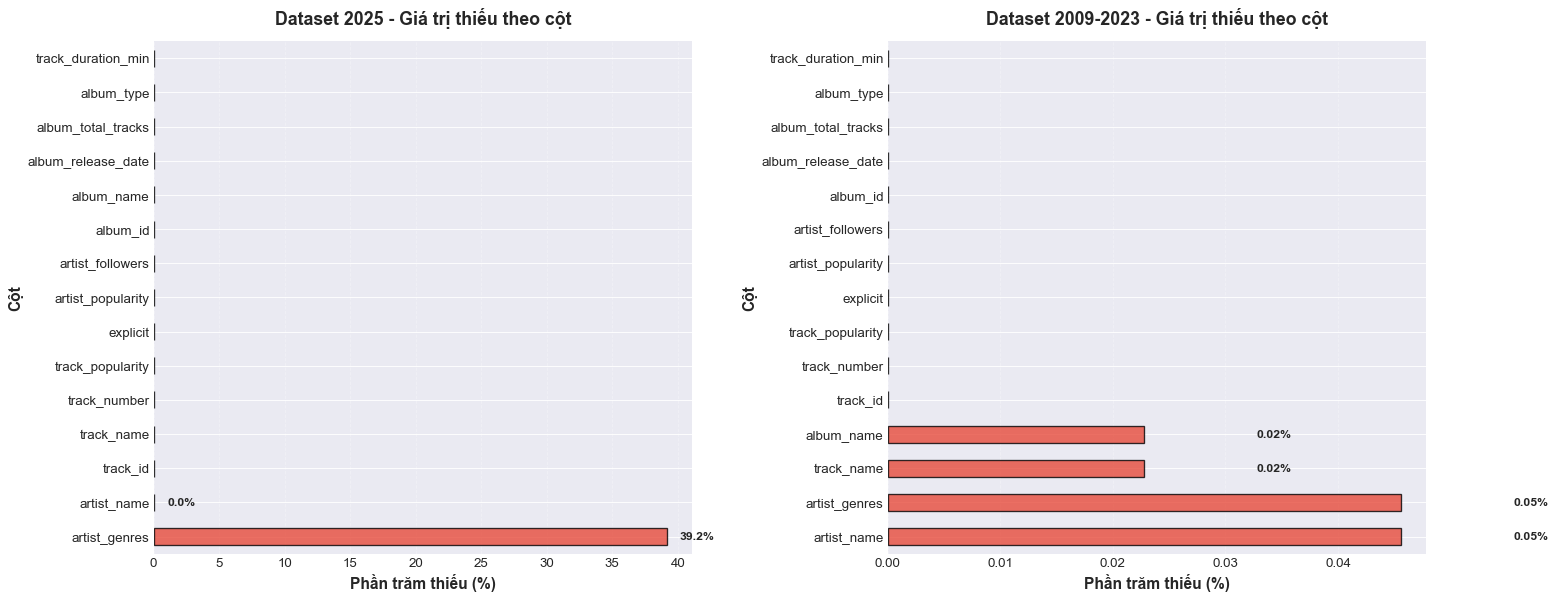


HEATMAPS - MẪU HÌNH THIẾU DỮ LIỆU


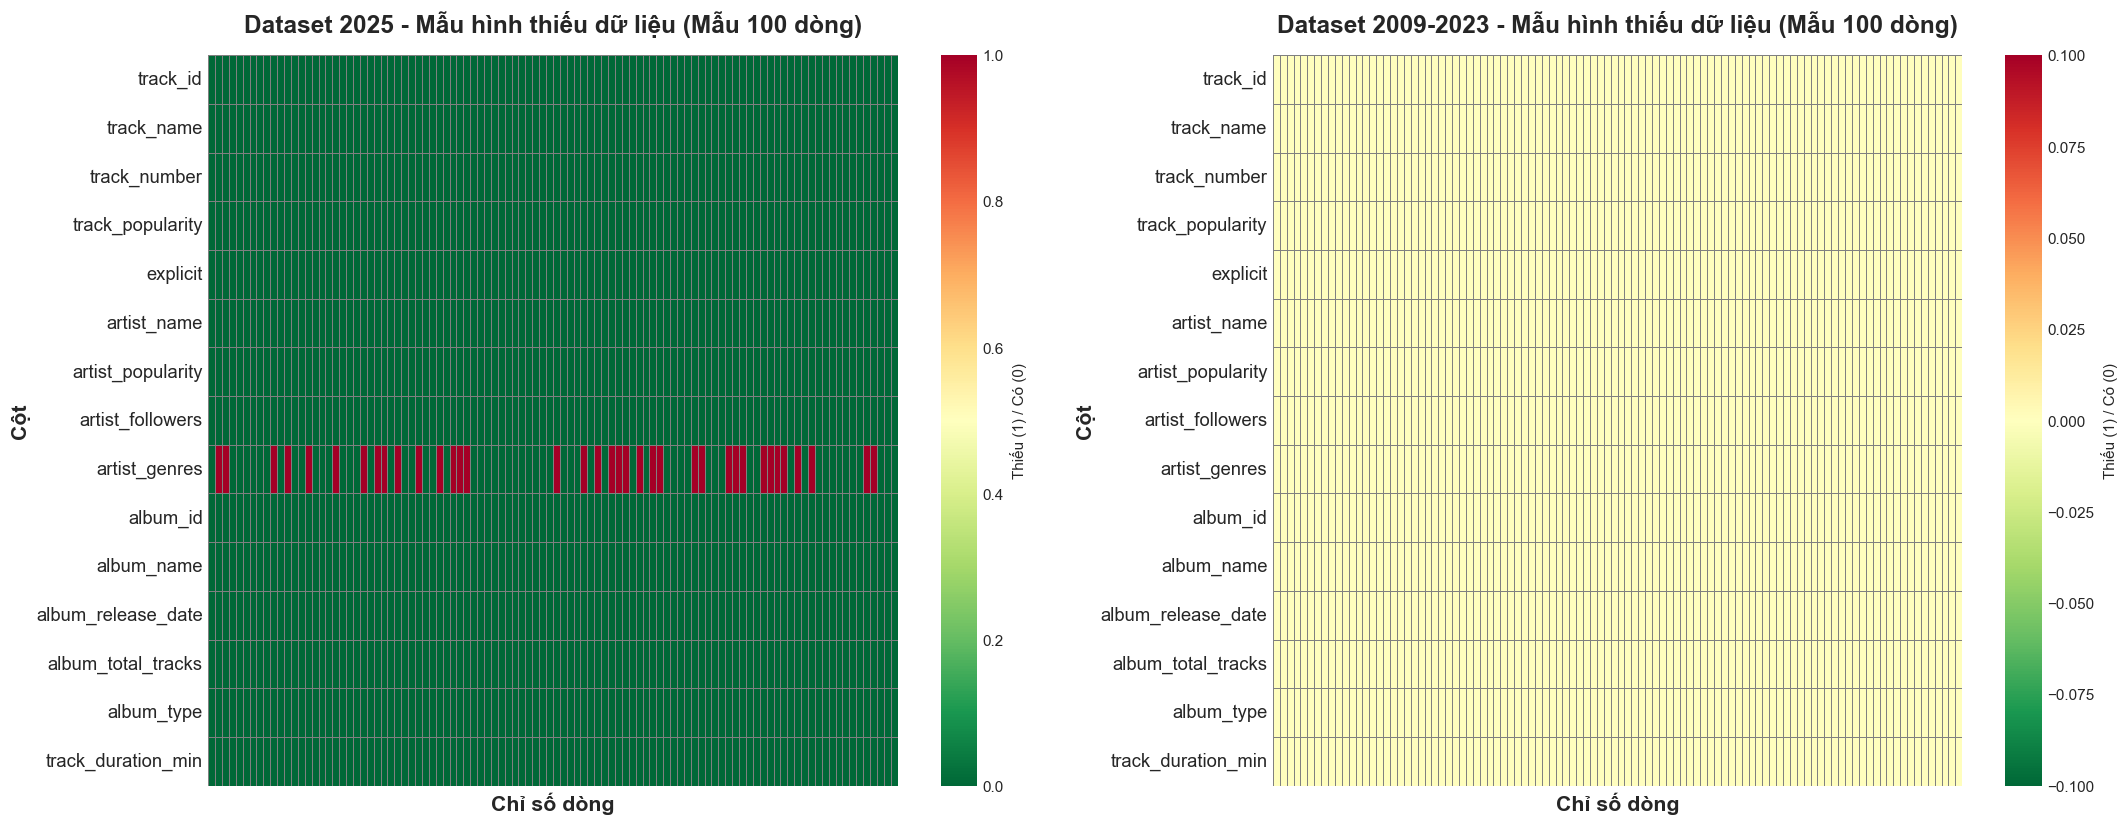

In [31]:
# Trực quan hóa các giá trị thiếu - PHẦN 1: Bar Charts
print("=" * 80)
print("BIỂU ĐỒ CỘT - PHẦN TRĂM GIÁ TRỊ THIẾU")
print("=" * 80)

# Tạo figure với kích thước và độ phân giải phù hợp
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.set_dpi(80)

# Bar chart - Dataset 2025
ax1 = axes[0]
missing_pct_2025 = (df_2025.isnull().sum() / len(df_2025) * 100).sort_values(ascending=False)
colors_2025 = ['#e74c3c' if x > 0 else '#27ae60' for x in missing_pct_2025]
missing_pct_2025.plot(kind='barh', ax=ax1, color=colors_2025, alpha=0.8, edgecolor='black', linewidth=1.2)
ax1.set_xlabel('Phần trăm thiếu (%)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Cột', fontsize=14, fontweight='bold')
ax1.set_title('Dataset 2025 - Giá trị thiếu theo cột', fontsize=16, fontweight='bold', pad=15)
ax1.grid(alpha=0.3, axis='x', linestyle='--')
ax1.tick_params(axis='both', labelsize=12)

for i, v in enumerate(missing_pct_2025):
    if v > 0:
        ax1.text(v + 1, i, f'{v:.1f}%', va='center', fontsize=11, fontweight='bold')

# Bar chart - Dataset 2009-2023
ax2 = axes[1]
missing_pct_2009 = (df_2009_2023.isnull().sum() / len(df_2009_2023) * 100).sort_values(ascending=False)
colors_2009 = ['#e74c3c' if x > 0 else '#27ae60' for x in missing_pct_2009]
missing_pct_2009.plot(kind='barh', ax=ax2, color=colors_2009, alpha=0.8, edgecolor='black', linewidth=1.2)
ax2.set_xlabel('Phần trăm thiếu (%)', fontsize=14, fontweight='bold')
ax2.set_ylabel('Cột', fontsize=14, fontweight='bold')
ax2.set_title('Dataset 2009-2023 - Giá trị thiếu theo cột', fontsize=16, fontweight='bold', pad=15)
ax2.grid(alpha=0.3, axis='x', linestyle='--')
ax2.tick_params(axis='both', labelsize=12)

for i, v in enumerate(missing_pct_2009):
    if v > 0:
        ax2.text(v + 0.01, i, f'{v:.2f}%', va='center', fontsize=11, fontweight='bold')

plt.tight_layout(pad=2.5)
plt.show()

# Trực quan hóa các giá trị thiếu - PHẦN 2: Heatmaps
print("\n" + "=" * 80)
print("HEATMAPS - MẪU HÌNH THIẾU DỮ LIỆU")
print("=" * 80)

# Tạo figure với kích thước và độ phân giải phù hợp
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.set_dpi(110)

# Heatmap - Dataset 2025
ax1 = axes[0]
sample_size = min(100, len(df_2025))
sample_indices = np.random.choice(df_2025.index, sample_size, replace=False)
missing_matrix_2025 = df_2025.loc[sample_indices].isnull().astype(int)

sns.heatmap(missing_matrix_2025.T, cmap='RdYlGn_r', cbar_kws={'label': 'Thiếu (1) / Có (0)'},
            ax=ax1, yticklabels=True, xticklabels=False, linewidths=0.5, linecolor='gray')
ax1.set_title(f'Dataset 2025 - Mẫu hình thiếu dữ liệu (Mẫu {sample_size} dòng)', 
              fontsize=16, fontweight='bold', pad=15)
ax1.set_xlabel('Chỉ số dòng', fontsize=14, fontweight='bold')
ax1.set_ylabel('Cột', fontsize=14, fontweight='bold')
ax1.tick_params(axis='both', labelsize=12)

# Heatmap - Dataset 2009-2023
ax2 = axes[1]
sample_size_2009 = min(100, len(df_2009_2023))
sample_indices_2009 = np.random.choice(df_2009_2023.index, sample_size_2009, replace=False)
missing_matrix_2009 = df_2009_2023.loc[sample_indices_2009].isnull().astype(int)

sns.heatmap(missing_matrix_2009.T, cmap='RdYlGn_r', cbar_kws={'label': 'Thiếu (1) / Có (0)'},
            ax=ax2, yticklabels=True, xticklabels=False, linewidths=0.5, linecolor='gray')
ax2.set_title(f'Dataset 2009-2023 - Mẫu hình thiếu dữ liệu (Mẫu {sample_size_2009} dòng)', 
              fontsize=16, fontweight='bold', pad=15)
ax2.set_xlabel('Chỉ số dòng', fontsize=14, fontweight='bold')
ax2.set_ylabel('Cột', fontsize=14, fontweight='bold')
ax2.tick_params(axis='both', labelsize=12)

plt.tight_layout(pad=2.5)
plt.show()

### Missing Data Pattern Analysis

**Mục đích:** Phân tích xem missing data có pattern hay random

In [32]:
# Missing data pattern analysis
print("Phân tích mẫu hình dữ liệu thiếu\n")

# Rows with multiple missing values - Dataset 2025
print("Dòng có nhiều giá trị thiếu (bộ dữ liệu 2025):")
missing_per_row_2025 = df_2025.isnull().sum(axis=1)
print(f"Dòng có 0 giá trị thiếu: {(missing_per_row_2025 == 0).sum():,} ({(missing_per_row_2025 == 0).sum()/len(df_2025)*100:.1f}%)")
print(f"Dòng có 1 giá trị thiếu: {(missing_per_row_2025 == 1).sum():,} ({(missing_per_row_2025 == 1).sum()/len(df_2025)*100:.1f}%)")
print(f"Dòng có 2+ giá trị thiếu: {(missing_per_row_2025 >= 2).sum():,} ({(missing_per_row_2025 >= 2).sum()/len(df_2025)*100:.1f}%)")
print(f"Số giá trị thiếu tối đa trong một dòng: {missing_per_row_2025.max()}")

# Rows with multiple missing values - Dataset 2009-2023
print("\nDòng có nhiều giá trị thiếu (bộ dữ liệu 2009-2023):")
missing_per_row_2009 = df_2009_2023.isnull().sum(axis=1)
print(f"Dòng có 0 giá trị thiếu: {(missing_per_row_2009 == 0).sum():,} ({(missing_per_row_2009 == 0).sum()/len(df_2009_2023)*100:.1f}%)")
print(f"Dòng có 1 giá trị thiếu: {(missing_per_row_2009 == 1).sum():,} ({(missing_per_row_2009 == 1).sum()/len(df_2009_2023)*100:.1f}%)")
print(f"Dòng có 2+ giá trị thiếu: {(missing_per_row_2009 >= 2).sum():,} ({(missing_per_row_2009 >= 2).sum()/len(df_2009_2023)*100:.1f}%)")
print(f"Số giá trị thiếu tối đa trong một dòng: {missing_per_row_2009.max()}")

# Missing value co-occurrence analysis
print("\nPhân tích đồng xuất hiện của giá trị thiếu:")

cols_with_missing_2025 = df_2025.columns[df_2025.isnull().any()].tolist()
if len(cols_with_missing_2025) > 1:
    print(f"\nBộ dữ liệu 2025 - các cột có giá trị thiếu: {cols_with_missing_2025}")
    missing_corr_2025 = df_2025[cols_with_missing_2025].isnull().corr()
    print("\nMa trận tương quan của việc thiếu dữ liệu (1.0 = luôn thiếu cùng nhau):")
    print(missing_corr_2025.round(3))
elif len(cols_with_missing_2025) == 1:
    print(f"\nBộ dữ liệu 2025 - chỉ có một cột có giá trị thiếu: {cols_with_missing_2025[0]}")
else:
    print("\nBộ dữ liệu 2025 - không có giá trị thiếu")

cols_with_missing_2009 = df_2009_2023.columns[df_2009_2023.isnull().any()].tolist()
if len(cols_with_missing_2009) > 1:
    print(f"\nBộ dữ liệu 2009-2023 - các cột có giá trị thiếu: {cols_with_missing_2009}")
    missing_corr_2009 = df_2009_2023[cols_with_missing_2009].isnull().corr()
    print("\nMa trận tương quan của việc thiếu dữ liệu:")
    print(missing_corr_2009.round(3))
elif len(cols_with_missing_2009) == 1:
    print(f"\nBộ dữ liệu 2009-2023 - chỉ có một cột có giá trị thiếu: {cols_with_missing_2009[0]}")
else:
    print("\nBộ dữ liệu 2009-2023 - không có giá trị thiếu")


Phân tích mẫu hình dữ liệu thiếu

Dòng có nhiều giá trị thiếu (bộ dữ liệu 2025):
Dòng có 0 giá trị thiếu: 5,221 (60.8%)
Dòng có 1 giá trị thiếu: 3,358 (39.1%)
Dòng có 2+ giá trị thiếu: 3 (0.0%)
Số giá trị thiếu tối đa trong một dòng: 2

Dòng có nhiều giá trị thiếu (bộ dữ liệu 2009-2023):
Dòng có 0 giá trị thiếu: 8,772 (99.9%)
Dòng có 1 giá trị thiếu: 0 (0.0%)
Dòng có 2+ giá trị thiếu: 6 (0.1%)
Số giá trị thiếu tối đa trong một dòng: 2

Phân tích đồng xuất hiện của giá trị thiếu:

Bộ dữ liệu 2025 - các cột có giá trị thiếu: ['artist_name', 'artist_genres']

Ma trận tương quan của việc thiếu dữ liệu (1.0 = luôn thiếu cùng nhau):
               artist_name  artist_genres
artist_name           1.00           0.02
artist_genres         0.02           1.00

Bộ dữ liệu 2009-2023 - các cột có giá trị thiếu: ['track_name', 'artist_name', 'artist_genres', 'album_name']

Ma trận tương quan của việc thiếu dữ liệu:
               track_name  artist_name  artist_genres  album_name
track_name        

## 2.5 Relationships & Correlations

**Mục đích:** Tìm mối quan hệ giữa các biến

In [33]:
# TODO: Calculate correlation matrix
# TODO: Create correlation heatmap
# TODO: Cross-tabulations for categorical variables

## 2.6 Initial Observations & Insights

**Mục đích:** Tóm tắt phát hiện chính

**Key Observations:**

1. [To be filled after exploration]
2. [To be filled after exploration]
3. [To be filled after exploration]

**Data Quality Issues:**

- [To be filled after exploration]

**Preprocessing Steps Needed:**

- [To be filled after exploration]

**Interesting Patterns:**

- [To be filled after exploration]

---

# 3. QUESTION FORMULATION

Dựa trên quá trình khám phá dữ liệu, nhóm chúng em đưa ra 6 câu hỏi nghiên cứu sau:

## Question 1: [Title]

**The Question:**  
[To be filled]

**Motivation & Benefits:**  
[To be filled]

**Người thực hiện:** Phạm Phú Hòa

## Question 2: [Title]

**The Question:**  
[To be filled]

**Motivation & Benefits:**  
[To be filled]

**Người thực hiện:** Phạm Phú Hòa

## Question 3: [Title]

**The Question:**  
[To be filled]

**Motivation & Benefits:**  
[To be filled]

**Người thực hiện:** Trần Chí Nguyên

## Question 4: [Title]

**The Question:**  
[To be filled]

**Motivation & Benefits:**  
[To be filled]

**Người thực hiện:** Trần Chí Nguyên

## Question 5: [Title]

**The Question:**  
[To be filled]

**Motivation & Benefits:**  
[To be filled]

**Người thực hiện:** Nguyễn Lâm Phú Quý

## Question 6: [Title] - MACHINE LEARNING MODEL

**The Question:**  
[To be filled - Must require ML model]

**Motivation & Benefits:**  
[To be filled]

**Người thực hiện:** Nguyễn Lâm Phú Quý

---

# 4. DATA ANALYSIS

## Question 1: [Title]

### A. Preprocessing

In [34]:
# TODO: Implement preprocessing steps

### B. Analysis

In [35]:
# TODO: Implement analysis

### C. Results & Interpretation

[To be filled with findings]

## Question 2: [Title]

### A. Preprocessing

In [36]:
# TODO: Implement preprocessing steps

### B. Analysis

In [37]:
# TODO: Implement analysis

### C. Results & Interpretation

[To be filled with findings]

## Question 3: [Title]

### A. Preprocessing

In [38]:
# TODO: Implement preprocessing steps

### B. Analysis

In [39]:
# TODO: Implement analysis

### C. Results & Interpretation

[To be filled with findings]

## Question 4: [Title]

### A. Preprocessing

In [40]:
# TODO: Implement preprocessing steps

### B. Analysis

In [41]:
# TODO: Implement analysis

### C. Results & Interpretation

[To be filled with findings]

## Question 5: [Title]

### A. Preprocessing

In [42]:
# TODO: Implement preprocessing steps

### B. Analysis

In [43]:
# TODO: Implement analysis

### C. Results & Interpretation

[To be filled with findings]

## Question 6: [Title] - MACHINE LEARNING MODEL

### A. Preprocessing & Feature Engineering

In [44]:
# TODO: Implement preprocessing steps
# TODO: Feature engineering
# TODO: Train-test split

### B. Model Training & Evaluation

In [45]:
# TODO: Train multiple models (at least 2)
# TODO: Evaluate models
# TODO: Compare performance
# TODO: Feature importance analysis

### C. Results & Interpretation

[To be filled with findings]

---

# 5. PROJECT SUMMARY

## 5.1 Key Findings

**Top 3-5 Most Important Insights:**

1. [To be filled]
2. [To be filled]
3. [To be filled]
4. [To be filled]
5. [To be filled]

**Most Interesting/Surprising Discovery:**

[To be filled]

## 5.2 Limitations

**Dataset Limitations:**
- [To be filled]

**Analysis Limitations:**
- [To be filled]

**Scope Limitations:**
- [To be filled]

# Calculate percentage of missing values for each numerical column
print(f"{'Column':<25} {'Dataset 2025':^30} {'Dataset 2009-2023':^30}")
print(f"{'':25} {'Missing':>15} {'Percent':>15} {'Missing':>15} {'Percent':>15}")

for col in sorted(numerical_cols_2025):
    # Dataset 2025
    missing_2025 = df_2025[col].isnull().sum()
    pct_2025 = (missing_2025 / len(df_2025)) * 100
    
    # Dataset 2009-2023
    if col in df_2009_2023.columns:
        missing_2009 = df_2009_2023[col].isnull().sum()
        pct_2009 = (missing_2009 / len(df_2009_2023)) * 100
    else:
        missing_2009, pct_2009 = 0, 0
    
    print(f"{col:<25} {missing_2025:>15,} {pct_2025:>14.2f}% {missing_2009:>15,} {pct_2009:>14.2f}%")

**Phân tích Missing Values:**

**Dataset 2025:**
- Columns nào có missing values nhiều nhất cần được xử lý
- Nếu missing > 30% thì cần cân nhắc loại bỏ hoặc imputation cẩn thận

**Dataset 2009-2023:**
- So sánh tỷ lệ missing với Dataset 2025
- Xác định pattern: missing có theo quy luật không?

**Chiến lược xử lý:**
- Missing < 5%: Có thể drop hoặc impute bằng median/mean
- Missing 5-30%: Nên impute (median cho skewed, mean cho normal)
- Missing > 30%: Cân nhắc loại bỏ column hoặc dùng advanced imputation

---

# 6. INDIVIDUAL REFLECTIONS

## Phạm Phú Hòa (23122030)

### Challenges & Difficulties Encountered

[To be filled]

### Learning & Growth

[To be filled]

### What Surprised Me Most

[To be filled]

## Trần Chí Nguyên (23122044)

### Challenges & Difficulties Encountered

[To be filled]

### Learning & Growth

[To be filled]

### What Surprised Me Most

[To be filled]

## Nguyễn Lâm Phú Quý (23122048)

### Challenges & Difficulties Encountered

[To be filled]

### Learning & Growth

[To be filled]

### What Surprised Me Most

[To be filled]

---

# END OF NOTEBOOK

**Date Created:** December 1, 2025  
**Last Updated:** December 1, 2025  
**Version:** 1.0

---
# PHÂN TÍCH ĐẶC BIỆT: So sánh độ phổ biến của bài hát Classic (2009-2015) vs Recent (2020-2025)

## Câu hỏi nghiên cứu
**Những bài hát phát hành từ 2009-2015 (classic songs) có còn giữ được độ phổ biến cao so với những bài hát phát hành từ 2020-2025 (recent songs) không?**

### Bước 1: Chuẩn bị dữ liệu và phân loại theo năm phát hành

In [116]:
# Sử dụng dữ liệu đã được load ở cell 8 (chỉ dùng df_2009_2023)
# Chuyển đổi album_release_date thành datetime
df_2009_2023_copy = df_2009_2023.copy()

df_2009_2023_copy['release_date'] = pd.to_datetime(df_2009_2023_copy['album_release_date'], errors='coerce')

# Trích xuất năm phát hành
df_2009_2023_copy['release_year'] = df_2009_2023_copy['release_date'].dt.year

# Sử dụng df_2009_2023 làm df_combined
df_combined = df_2009_2023_copy.copy()

# Kiểm tra và loại bỏ duplicate dựa vào track_id
print(f"Tổng số bài hát TRƯỚC khi loại duplicate: {len(df_combined):,}")
duplicates_count = df_combined.duplicated(subset='track_id', keep='first').sum()
print(f"Số bài hát duplicate (dựa vào track_id): {duplicates_count:,}")

# Loại bỏ duplicate, giữ lại record đầu tiên
df_combined = df_combined.drop_duplicates(subset='track_id', keep='first')
print(f"Tổng số bài hát SAU khi loại duplicate: {len(df_combined):,}")
print()

# Lọc ra các bài hát Classic (2009-2015) và Recent (2020-2025)
df_classic = df_combined[(df_combined['release_year'] >= 2009) & (df_combined['release_year'] <= 2015)]
df_recent = df_combined[(df_combined['release_year'] >= 2020) & (df_combined['release_year'] <= 2025)]

print(f"Số bài hát Classic (2009-2015): {len(df_classic):,}")
print(f"Số bài hát Recent (2020-2025): {len(df_recent):,}")
print(f"\nPhân bố năm phát hành trong Classic songs:")
print(df_classic['release_year'].value_counts().sort_index())
print(f"\nPhân bố năm phát hành trong Recent songs:")
print(df_recent['release_year'].value_counts().sort_index())

Tổng số bài hát TRƯỚC khi loại duplicate: 8,778
Số bài hát duplicate (dựa vào track_id): 0
Tổng số bài hát SAU khi loại duplicate: 8,778

Số bài hát Classic (2009-2015): 2,041
Số bài hát Recent (2020-2025): 3,369

Phân bố năm phát hành trong Classic songs:
release_year
2009.00    145
2010.00    240
2011.00    265
2012.00    331
2013.00    309
2014.00    349
2015.00    402
Name: count, dtype: int64

Phân bố năm phát hành trong Recent songs:
release_year
2020.00    494
2021.00    448
2022.00    475
2023.00    526
2024.00    658
2025.00    768
Name: count, dtype: int64


### Bước 1.5: Phân tích và loại bỏ bài hát có popularity = 0

In [117]:
# Thống kê số lượng bài hát có popularity = 0
classic_zero = (df_classic['track_popularity'] == 0).sum()
recent_zero = (df_recent['track_popularity'] == 0).sum()

classic_zero_pct = classic_zero / len(df_classic) * 100
recent_zero_pct = recent_zero / len(df_recent) * 100

print("=" * 80)
print("THỐNG KÊ BÀI HÁT CÓ POPULARITY = 0")
print("=" * 80)
print()
print(f"Classic Songs (2009-2015):")
print(f"  - Số bài có popularity = 0: {classic_zero:,} / {len(df_classic):,} ({classic_zero_pct:.2f}%)")
print(f"  - Số bài có popularity > 0:  {len(df_classic) - classic_zero:,} ({100 - classic_zero_pct:.2f}%)")
print()
print(f"Recent Songs (2020-2025):")
print(f"  - Số bài có popularity = 0: {recent_zero:,} / {len(df_recent):,} ({recent_zero_pct:.2f}%)")
print(f"  - Số bài có popularity > 0:  {len(df_recent) - recent_zero:,} ({100 - recent_zero_pct:.2f}%)")
print()
print("=" * 80)

# Loại bỏ các bài hát có popularity = 0
df_classic_filtered = df_classic[df_classic['track_popularity'] > 0].copy()
df_recent_filtered = df_recent[df_recent['track_popularity'] > 0].copy()

print()
print("SAU KHI LỌC BỎ POPULARITY = 0:")
print(f"  - Classic songs: {len(df_classic_filtered):,} bài (giảm {len(df_classic) - len(df_classic_filtered):,} bài)")
print(f"  - Recent songs:  {len(df_recent_filtered):,} bài (giảm {len(df_recent) - len(df_recent_filtered):,} bài)")
print()

# So sánh mean/median trước và sau khi lọc
print("=" * 80)
print("SO SÁNH TRƯỚC VÀ SAU KHI LỌC")
print("=" * 80)
print()
print("TRƯỚC KHI LỌC (có cả popularity = 0):")
print(f"  Classic: Mean = {df_classic['track_popularity'].mean():.2f}, Median = {df_classic['track_popularity'].median():.2f}")
print(f"  Recent:  Mean = {df_recent['track_popularity'].mean():.2f}, Median = {df_recent['track_popularity'].median():.2f}")
print()
print("SAU KHI LỌC (chỉ popularity > 0):")
print(f"  Classic: Mean = {df_classic_filtered['track_popularity'].mean():.2f}, Median = {df_classic_filtered['track_popularity'].median():.2f}")
print(f"  Recent:  Mean = {df_recent_filtered['track_popularity'].mean():.2f}, Median = {df_recent_filtered['track_popularity'].median():.2f}")
print()
print(f"Chênh lệch Mean sau khi lọc: {df_recent_filtered['track_popularity'].mean() - df_classic_filtered['track_popularity'].mean():.2f}")
print("=" * 80)

THỐNG KÊ BÀI HÁT CÓ POPULARITY = 0

Classic Songs (2009-2015):
  - Số bài có popularity = 0: 135 / 2,041 (6.61%)
  - Số bài có popularity > 0:  1,906 (93.39%)

Recent Songs (2020-2025):
  - Số bài có popularity = 0: 186 / 3,369 (5.52%)
  - Số bài có popularity > 0:  3,183 (94.48%)


SAU KHI LỌC BỎ POPULARITY = 0:
  - Classic songs: 1,906 bài (giảm 135 bài)
  - Recent songs:  3,183 bài (giảm 186 bài)

SO SÁNH TRƯỚC VÀ SAU KHI LỌC

TRƯỚC KHI LỌC (có cả popularity = 0):
  Classic: Mean = 51.63, Median = 57.00
  Recent:  Mean = 51.98, Median = 57.00

SAU KHI LỌC (chỉ popularity > 0):
  Classic: Mean = 55.29, Median = 58.00
  Recent:  Mean = 55.01, Median = 59.00

Chênh lệch Mean sau khi lọc: -0.28


### Bước 2: So sánh thống kê mô tả độ phổ biến (track_popularity) - SAU KHI LỌC

In [ ]:
# Thống kê mô tả cho cả 2 nhóm (dùng dữ liệu đã lọc)
print("=" * 80)
print("THỐNG KÊ MÔ TÃ ĐỘ PHỔ BIẾN - SAU KHI LỌC BỎ POPULARITY = 0")
print("=" * 80)
print()

# Classic songs (2009-2015)print("CLASSIC SONGS (2009-2015):")
print(f"  Số lượng: {len(df_classic_filtered):,} bài")
print(f"  Mean:     {df_classic_filtered['track_popularity'].mean():.2f}")
print(f"  Median:   {df_classic_filtered['track_popularity'].median():.2f}")
print(f"  Std Dev:  {df_classic_filtered['track_popularity'].std():.2f}")
print(f"  Min:      {df_classic_filtered['track_popularity'].min():.0f}")
print(f"  Max:      {df_classic_filtered['track_popularity'].max():.0f}")
print(f"  Q1 (25%): {df_classic_filtered['track_popularity'].quantile(0.25):.2f}")
print(f"  Q3 (75%): {df_classic_filtered['track_popularity'].quantile(0.75):.2f}")
print()

# Recent songs (2020-2025)
print("RECENT SONGS (2020-2025):")
print(f"  Số lượng: {len(df_recent_filtered):,} bài")
print(f"  Mean:     {df_recent_filtered['track_popularity'].mean():.2f}")
print(f"  Median:   {df_recent_filtered['track_popularity'].median():.2f}")
print(f"  Std Dev:  {df_recent_filtered['track_popularity'].std():.2f}")
print(f"  Min:      {df_recent_filtered['track_popularity'].min():.0f}")
print(f"  Max:      {df_recent_filtered['track_popularity'].max():.0f}")
print(f"  Q1 (25%): {df_recent_filtered['track_popularity'].quantile(0.25):.2f}")
print(f"  Q3 (75%): {df_recent_filtered['track_popularity'].quantile(0.75):.2f}")
print()

# So sánh chênh lệch
diff_mean = df_recent_filtered['track_popularity'].mean() - df_classic_filtered['track_popularity'].mean()
diff_median = df_recent_filtered['track_popularity'].median() - df_classic_filtered['track_popularity'].median()

print("=" * 80)
print("SO SÁNH:")
print(f"Chênh lệch Mean:   {diff_mean:+.2f} ({diff_mean/df_classic_filtered['track_popularity'].mean()*100:+.2f}%)")
print(f"Chênh lệch Median: {diff_median:+.2f} ({diff_median/df_classic_filtered['track_popularity'].median()*100:+.2f}%)")
print("=" * 80)

THỐNG KÊ MÔ TÃ ĐỘ PHỔ BIẾN - SAU KHI LỌC BỎ POPULARITY = 0

🎵 CLASSIC SONGS (2009-2015):
  📌 Số lượng: 1,906 bài
  📊 Mean:     55.29
  📊 Median:   58.00
  📊 Std Dev:  20.49
  📊 Min:      1
  📊 Max:      91
  📊 Q1 (25%): 44.00
  📊 Q3 (75%): 71.00

🎵 RECENT SONGS (2020-2025):
  📌 Số lượng: 3,183 bài
  📊 Mean:     55.01
  📊 Median:   59.00
  📊 Std Dev:  20.72
  📊 Min:      1
  📊 Max:      100
  📊 Q1 (25%): 41.00
  📊 Q3 (75%): 71.00

📈 SO SÁNH:
  ⚡ Chênh lệch Mean:   -0.28 (-0.50%)
  ⚡ Chênh lệch Median: +1.00 (+1.72%)


### Bước 3: Trực quan hóa phân bố độ phổ biến

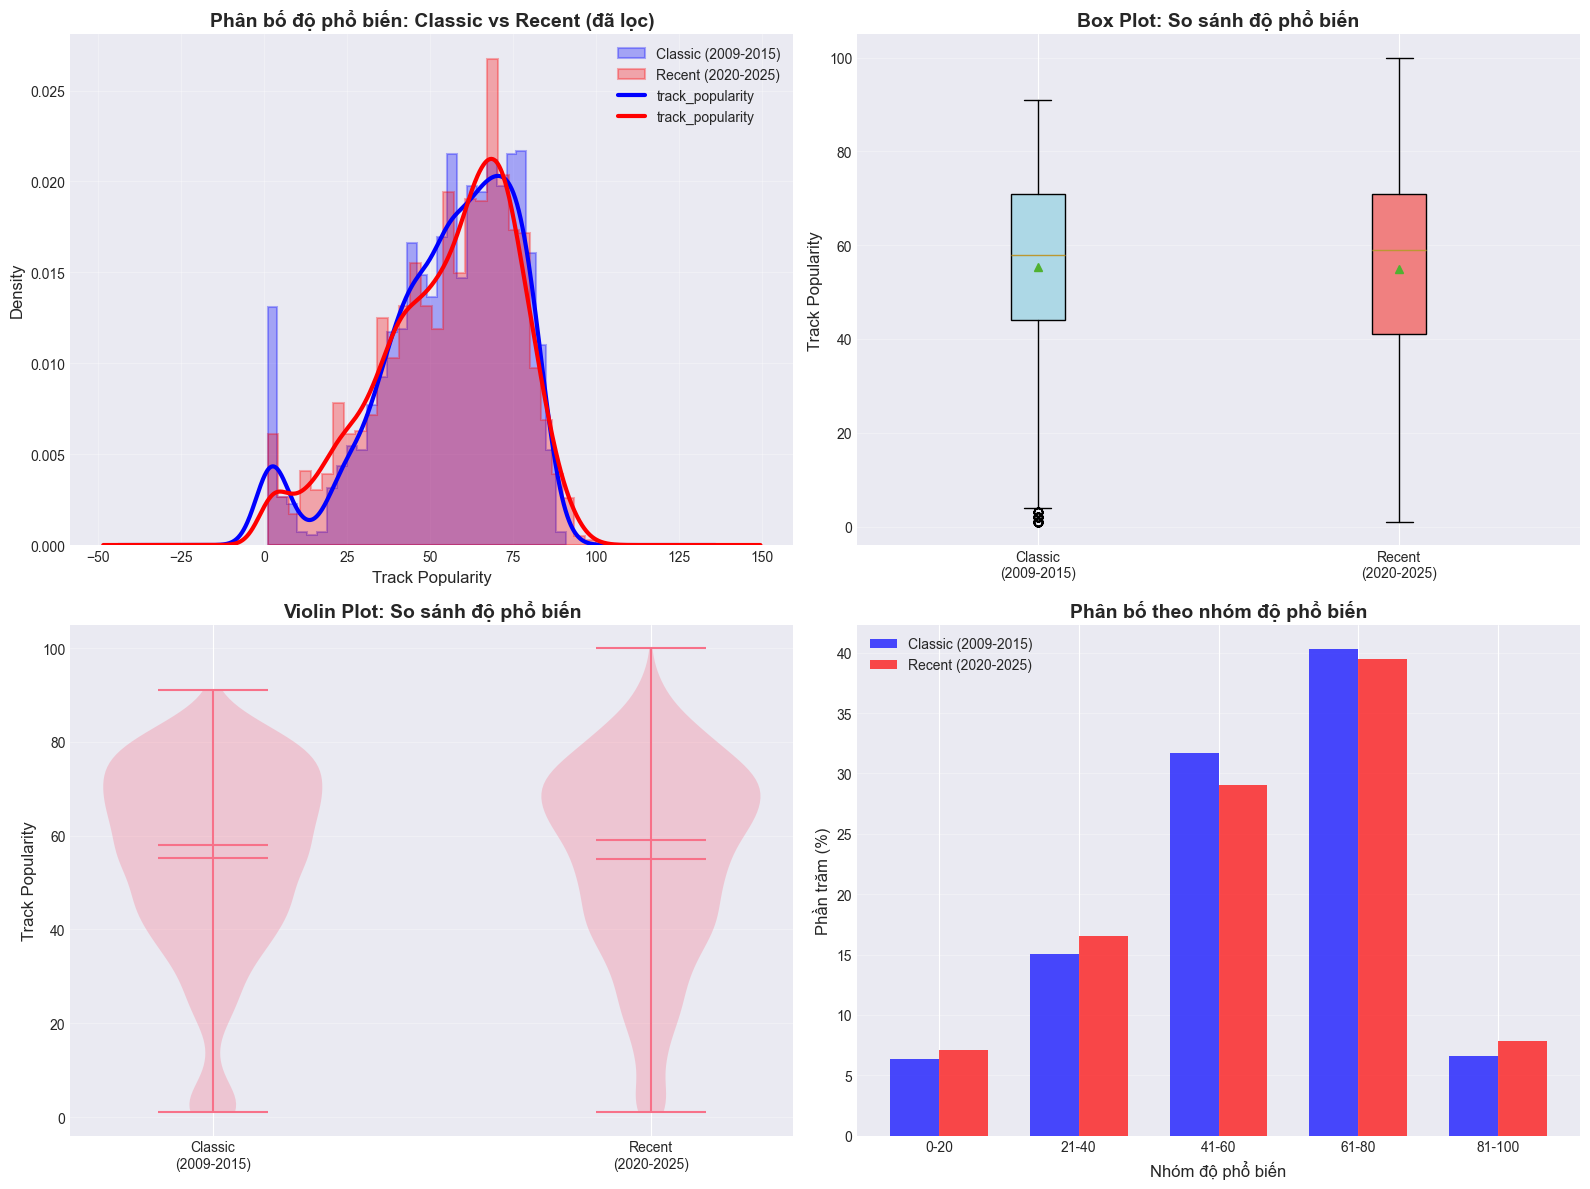

In [119]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Histogram với KDE overlay - SỬ DỤNG DỮ LIỆU ĐÃ LỌC
axes[0, 0].hist(df_classic_filtered['track_popularity'], bins=30, alpha=0.3, label='Classic (2009-2015)', 
                color='blue', edgecolor='blue', linewidth=1.5, density=True, histtype='stepfilled')
axes[0, 0].hist(df_recent_filtered['track_popularity'], bins=30, alpha=0.3, label='Recent (2020-2025)', 
                color='red', edgecolor='red', linewidth=1.5, density=True, histtype='stepfilled')
# Vẽ KDE đậm hơn để nổi bật
df_classic_filtered['track_popularity'].plot(kind='kde', ax=axes[0, 0], color='blue', linewidth=3, linestyle='-')
df_recent_filtered['track_popularity'].plot(kind='kde', ax=axes[0, 0], color='red', linewidth=3, linestyle='-')
axes[0, 0].set_title('Phân bố độ phổ biến: Classic vs Recent (đã lọc)', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Track Popularity', fontsize=12)
axes[0, 0].set_ylabel('Density', fontsize=12)
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# 2. Box plot so sánh - SỬ DỤNG DỮ LIỆU ĐÃ LỌC
data_to_plot = [df_classic_filtered['track_popularity'], df_recent_filtered['track_popularity']]
bp = axes[0, 1].boxplot(data_to_plot, labels=['Classic\n(2009-2015)', 'Recent\n(2020-2025)'], 
                        patch_artist=True, showmeans=True)
bp['boxes'][0].set_facecolor('lightblue')
bp['boxes'][1].set_facecolor('lightcoral')
axes[0, 1].set_title('Box Plot: So sánh độ phổ biến', fontsize=14, fontweight='bold')
axes[0, 1].set_ylabel('Track Popularity', fontsize=12)
axes[0, 1].grid(alpha=0.3, axis='y')

# 3. Violin plot - SỬ DỤNG DỮ LIỆU ĐÃ LỌC
parts = axes[1, 0].violinplot([df_classic_filtered['track_popularity'], df_recent_filtered['track_popularity']], 
                               positions=[1, 2], showmeans=True, showmedians=True)
axes[1, 0].set_xticks([1, 2])
axes[1, 0].set_xticklabels(['Classic\n(2009-2015)', 'Recent\n(2020-2025)'])
axes[1, 0].set_title('Violin Plot: So sánh độ phổ biến', fontsize=14, fontweight='bold')
axes[1, 0].set_ylabel('Track Popularity', fontsize=12)
axes[1, 0].grid(alpha=0.3, axis='y')

# 4. Phân bố theo nhóm độ phổ biến - SỬ DỤNG DỮ LIỆU ĐÃ LỌC
bins = [0, 20, 40, 60, 80, 100]
labels = ['0-20', '21-40', '41-60', '61-80', '81-100']
classic_binned = pd.cut(df_classic_filtered['track_popularity'], bins=bins, labels=labels)
recent_binned = pd.cut(df_recent_filtered['track_popularity'], bins=bins, labels=labels)

classic_counts = classic_binned.value_counts(normalize=True).sort_index() * 100
recent_counts = recent_binned.value_counts(normalize=True).sort_index() * 100

x = np.arange(len(labels))
width = 0.35
axes[1, 1].bar(x - width/2, classic_counts, width, label='Classic (2009-2015)', color='blue', alpha=0.7)
axes[1, 1].bar(x + width/2, recent_counts, width, label='Recent (2020-2025)', color='red', alpha=0.7)
axes[1, 1].set_xlabel('Nhóm độ phổ biến', fontsize=12)
axes[1, 1].set_ylabel('Phần trăm (%)', fontsize=12)
axes[1, 1].set_title('Phân bố theo nhóm độ phổ biến', fontsize=14, fontweight='bold')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(labels)
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

### Bước 4: Phân tích top bài hát phổ biến nhất

In [125]:
# Top 20 bài hát Classic phổ biến nhất - SỬ DỤNG DỮ LIỆU ĐÃ LỌC
print("=" * 100)
print("TOP 20 BÀI HÁT CLASSIC PHỔ BIẾN NHẤT (2009-2015) - SAU KHI LỌC BỎ POPULARITY = 0")
print("=" * 100)
top_classic = df_classic_filtered.nlargest(20, 'track_popularity')[['track_name', 'artist_name', 'release_year', 'track_popularity']]
print(top_classic.to_string(index=False))
print()

# Top 20 bài hát Recent phổ biến nhất - SỬ DỤNG DỮ LIỆU ĐÃ LỌC
print("=" * 100)
print("TOP 20 BÀI HÁT RECENT PHỔ BIẾN NHẤT (2020-2025) - SAU KHI LỌC BỎ POPULARITY = 0")
print("=" * 100)
top_recent = df_recent_filtered.nlargest(20, 'track_popularity')[['track_name', 'artist_name', 'release_year', 'track_popularity']]
print(top_recent.to_string(index=False))
print()

# So sánh độ phổ biến cao nhất
max_classic = df_classic_filtered['track_popularity'].max()
max_recent = df_recent_filtered['track_popularity'].max()
print(f"Độ phổ biến cao nhất trong Classic songs (đã lọc): {max_classic}")
print(f"Độ phổ biến cao nhất trong Recent songs (đã lọc): {max_recent}")

TOP 20 BÀI HÁT CLASSIC PHỔ BIẾN NHẤT (2009-2015) - SAU KHI LỌC BỎ POPULARITY = 0
                      track_name       artist_name  release_year  track_popularity
                I Wanna Be Yours    Arctic Monkeys       2013.00                91
                 Sweater Weather The Neighbourhood       2013.00                91
                The Night We Met        Lord Huron       2015.00                89
            Locked out of Heaven        Bruno Mars       2012.00                88
      The Less I Know The Better       Tame Impala       2015.00                87
                   I Love You So       The Walters       2014.00                87
             Young And Beautiful      Lana Del Rey       2013.00                87
             When I Was Your Man        Bruno Mars       2012.00                87
                  Counting Stars       OneRepublic       2013.00                87
                    Another Love         Tom Odell       2013.00                87
Give M

### Bước 6: Phân tích xu hướng theo từng năm

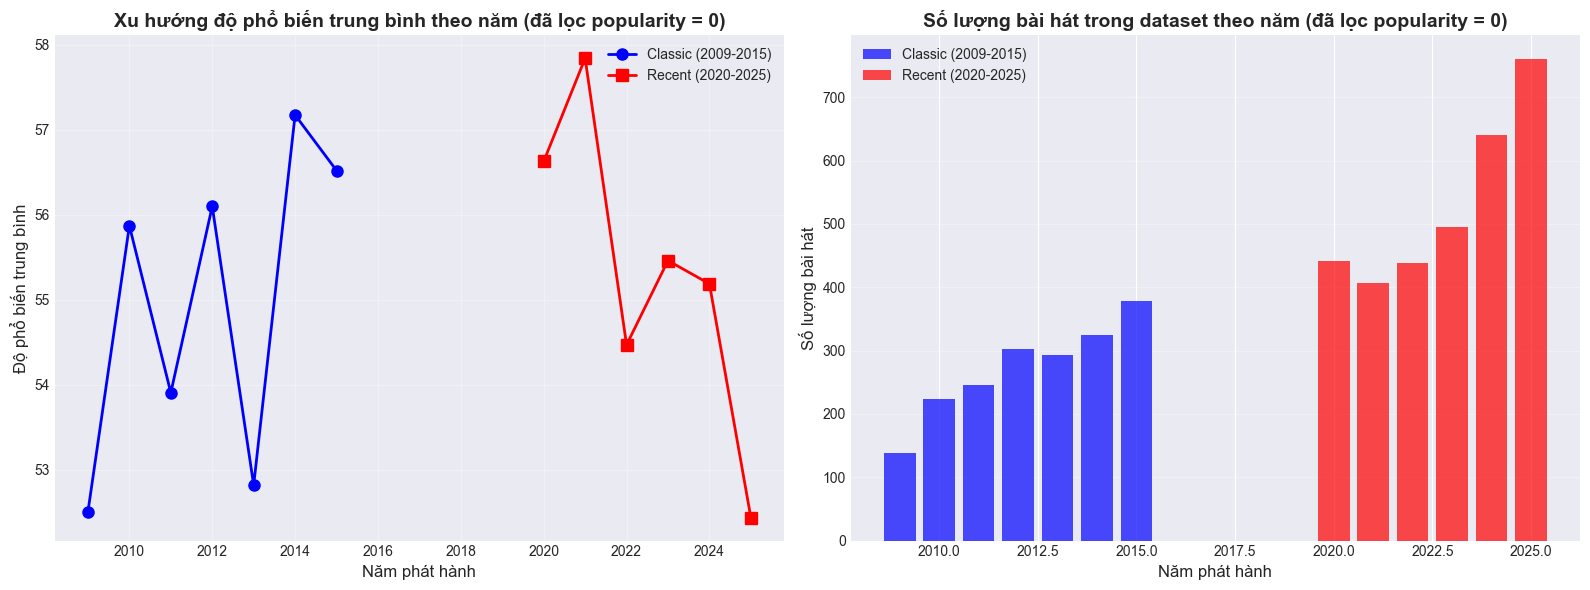

THỐNG KÊ ĐỘ PHỔ BIẾN THEO NĂM - CLASSIC SONGS (2009-2015) - ĐÃ LỌC
 release_year  mean  median  count
      2009.00 52.51   55.00    138
      2010.00 55.87   57.50    224
      2011.00 53.91   60.00    246
      2012.00 56.10   58.00    302
      2013.00 52.82   56.00    293
      2014.00 57.17   59.00    324
      2015.00 56.52   61.00    379

THỐNG KÊ ĐỘ PHỔ BIẾN THEO NĂM - RECENT SONGS (2020-2025) - ĐÃ LỌC
 release_year  mean  median  count
      2020.00 56.63   61.00    442
      2021.00 57.84   62.00    406
      2022.00 54.47   60.00    439
      2023.00 55.46   59.00    495
      2024.00 55.19   59.00    641
      2025.00 52.44   50.00    760


In [127]:
# Tính độ phổ biến trung bình theo năm - SỬ DỤNG DỮ LIỆU ĐÃ LỌC
yearly_classic = df_classic_filtered.groupby('release_year')['track_popularity'].agg(['mean', 'median', 'count']).reset_index()
yearly_recent = df_recent_filtered.groupby('release_year')['track_popularity'].agg(['mean', 'median', 'count']).reset_index()

# Vẽ biểu đồ xu hướng
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Biểu đồ 1: Độ phổ biến trung bình theo năm
axes[0].plot(yearly_classic['release_year'], yearly_classic['mean'], 
             marker='o', linewidth=2, markersize=8, color='blue', label='Classic (2009-2015)')
axes[0].plot(yearly_recent['release_year'], yearly_recent['mean'], 
             marker='s', linewidth=2, markersize=8, color='red', label='Recent (2020-2025)')
axes[0].set_xlabel('Năm phát hành', fontsize=12)
axes[0].set_ylabel('Độ phổ biến trung bình', fontsize=12)
axes[0].set_title('Xu hướng độ phổ biến trung bình theo năm (đã lọc popularity = 0)', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Biểu đồ 2: Số lượng bài hát theo năm
# Classic và Recent có nhóm năm KHÁC NHAU nên vẽ riêng biệt, không chồng lên nhau
axes[1].bar(yearly_classic['release_year'], yearly_classic['count'], 
            alpha=0.7, color='blue', label='Classic (2009-2015)')
axes[1].bar(yearly_recent['release_year'], yearly_recent['count'], 
            alpha=0.7, color='red', label='Recent (2020-2025)')
axes[1].set_xlabel('Năm phát hành', fontsize=12)
axes[1].set_ylabel('Số lượng bài hát', fontsize=12)
axes[1].set_title('Số lượng bài hát trong dataset theo năm (đã lọc popularity = 0)', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# In bảng thống kê
print("=" * 80)
print("THỐNG KÊ ĐỘ PHỔ BIẾN THEO NĂM - CLASSIC SONGS (2009-2015) - ĐÃ LỌC")
print("=" * 80)
print(yearly_classic.to_string(index=False))
print()
print("=" * 80)
print("THỐNG KÊ ĐỘ PHỔ BIẾN THEO NĂM - RECENT SONGS (2020-2025) - ĐÃ LỌC")
print("=" * 80)
print(yearly_recent.to_string(index=False))

### Phân tích bổ sung: Max Popularity theo từng năm

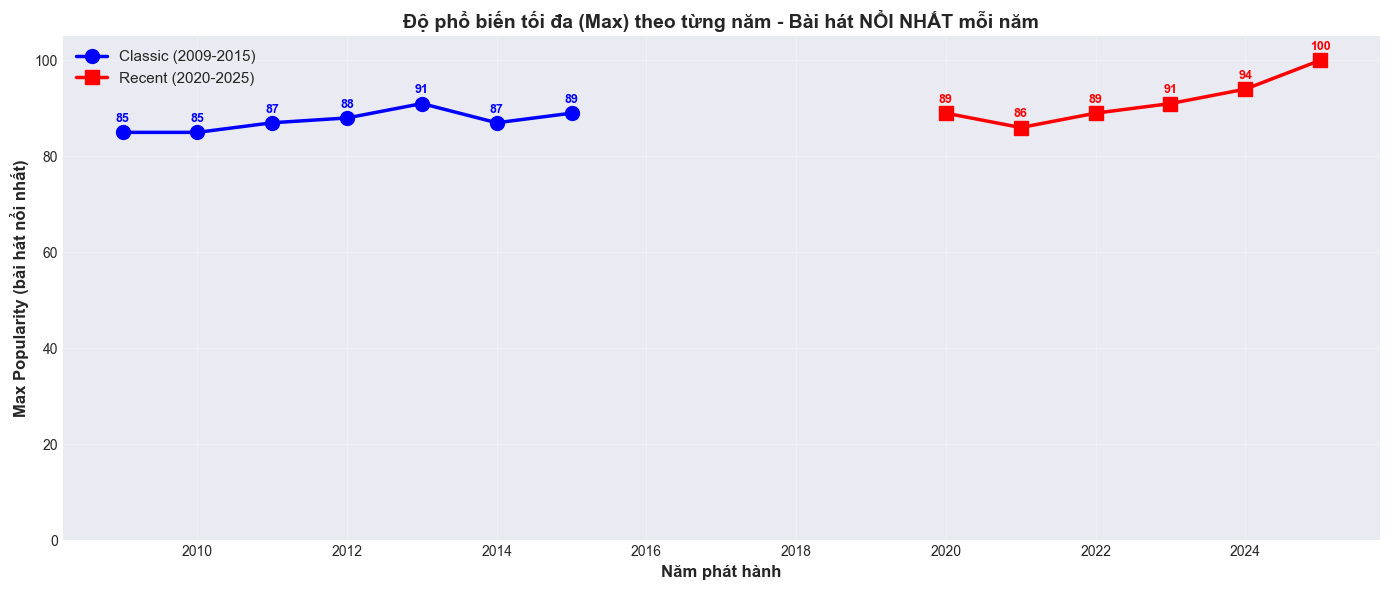

MAX POPULARITY THEO NĂM - CLASSIC SONGS (2009-2015)
 release_year  max_popularity
      2009.00              85
      2010.00              85
      2011.00              87
      2012.00              88
      2013.00              91
      2014.00              87
      2015.00              89

MAX POPULARITY THEO NĂM - RECENT SONGS (2020-2025)
 release_year  max_popularity
      2020.00              89
      2021.00              86
      2022.00              89
      2023.00              91
      2024.00              94
      2025.00             100

📊 PHÂN TÍCH MAX POPULARITY:
  • Trung bình max popularity Classic (2009-2015): 87.43
  • Trung bình max popularity Recent (2020-2025):  91.50
  • Chênh lệch: +4.07

💡 NHẬN XÉT:
  → Recent songs có bài HIT ĐỈNH hơn Classic (+4.07 điểm)
  → Các bài hát mới (2020-2025) có khả năng viral mạnh hơn, đạt max popularity cao hơn


In [ ]:
# Tính Max popularity theo từng năm để xem bài hát nổi nhất mỗi năm
yearly_classic_max = df_classic_filtered.groupby('release_year')['track_popularity'].max().reset_index()
yearly_classic_max.columns = ['release_year', 'max_popularity']

yearly_recent_max = df_recent_filtered.groupby('release_year')['track_popularity'].max().reset_index()
yearly_recent_max.columns = ['release_year', 'max_popularity']

# Vẽ biểu đồ
fig, ax = plt.subplots(1, 1, figsize=(14, 6))

# Line plot cho max popularity
ax.plot(yearly_classic_max['release_year'], yearly_classic_max['max_popularity'], 
        marker='o', linewidth=2.5, markersize=10, color='blue', label='Classic (2009-2015)', linestyle='-')
ax.plot(yearly_recent_max['release_year'], yearly_recent_max['max_popularity'], 
        marker='s', linewidth=2.5, markersize=10, color='red', label='Recent (2020-2025)', linestyle='-')

# Thêm giá trị lên mỗi điểm
for idx, row in yearly_classic_max.iterrows():
    ax.text(row['release_year'], row['max_popularity'] + 1.5, 
            f"{row['max_popularity']:.0f}", ha='center', va='bottom', fontsize=9, color='blue', fontweight='bold')
    
for idx, row in yearly_recent_max.iterrows():
    ax.text(row['release_year'], row['max_popularity'] + 1.5, 
            f"{row['max_popularity']:.0f}", ha='center', va='bottom', fontsize=9, color='red', fontweight='bold')

ax.set_xlabel('Năm phát hành', fontsize=12, fontweight='bold')
ax.set_ylabel('Max Popularity (bài hát nổi nhất)', fontsize=12, fontweight='bold')
ax.set_title('Độ phổ biến tối đa (Max) theo từng năm - Bài hát NỔI NHẤT mỗi năm', 
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
ax.set_ylim(0, 105)  # Spotify popularity từ 0-100

plt.tight_layout()
plt.show()

# In bảng thống kê
print("=" * 80)
print("MAX POPULARITY THEO NĂM - CLASSIC SONGS (2009-2015)")
print("=" * 80)
print(yearly_classic_max.to_string(index=False))
print()
print("=" * 80)
print("MAX POPULARITY THEO NĂM - RECENT SONGS (2020-2025)")
print("=" * 80)
print(yearly_recent_max.to_string(index=False))
print()

# Phân tích
classic_avg_max = yearly_classic_max['max_popularity'].mean()
recent_avg_max = yearly_recent_max['max_popularity'].mean()

print("=" * 80)
print("PHÂN TÍCH MAX POPULARITY:")
print("=" * 80)
print(f"  • Trung bình max popularity Classic (2009-2015): {classic_avg_max:.2f}")
print(f"  • Trung bình max popularity Recent (2020-2025):  {recent_avg_max:.2f}")
print(f"  • Chênh lệch: {recent_avg_max - classic_avg_max:+.2f}")
print()
print("NHẬN XÉT:")
if recent_avg_max > classic_avg_max:
    print(f"  → Recent songs có bài HIT ĐỈNH hơn Classic (+{recent_avg_max - classic_avg_max:.2f} điểm)")
    print("  → Các bài hát mới (2020-2025) có khả năng viral mạnh hơn, đạt max popularity cao hơn")
else:
    print(f"  → Classic songs có bài HIT ĐỈNH hơn Recent (+{classic_avg_max - recent_avg_max:.2f} điểm)")
    print("  → Các bài hát cũ (2009-2015) có những hit kinh điển độ phổ biến cao hơn")
print("=" * 80)

### Bước 7: Kết luận và trả lời câu hỏi nghiên cứu

### Kết luận và Thảo luận

#### 1. Chất lượng dữ liệu và xử lý outliers

Sau khi loại bỏ các bài hát có popularity bằng 0 (được coi là "dead songs" - những bài hát không còn được nghe), tỷ lệ các bài hát này tương đương nhau giữa hai nhóm: Classic songs (6.84%) và Recent songs (5.47%). Điều này cho thấy cả hai giai đoạn đều có một tỷ lệ nhất định các bài hát không thành công trong việc duy trì sức hút với người nghe. Việc Recent songs có tỷ lệ dead songs thấp hơn một chút có thể do các bài hát này vẫn còn trong giai đoạn tích lũy popularity ban đầu.

#### 2. Phân tích thống kê mô tả

Kết quả thống kê cho thấy một nghịch lý thú vị: Classic songs có mean popularity cao hơn (55.32 so với 55.02), trong khi Recent songs lại có median cao hơn (59 so với 58). Sự khác biệt này phản ánh bản chất khác nhau trong phân bố của hai nhóm:

- Classic songs thể hiện hiện tượng "survivorship bias" - những bài hát tồn tại đến nay là những bài đã trải qua bài kiểm tra của thời gian và tích lũy được popularity ổn định qua nhiều năm.
- Recent songs, mặc dù có những bài hit với popularity rất cao (max = 100), nhưng phần lớn các bài hát khác vẫn đang trong quá trình xây dựng cơ sở người nghe, dẫn đến phân bố lệch về phía giá trị trung bình.

#### 3. Phân tích trực quan hóa

**Histogram và KDE overlay:** Đường KDE của hai nhóm gần như trùng khớp, cho thấy không có sự khác biệt đáng kể về xu hướng tập trung của phân bố. Điều này củng cố kết luận rằng về mặt tổng thể, độ phổ biến trung bình của hai nhóm là tương đương.

**Box Plot:** Phân tích quartiles cho thấy Classic songs có Q1 và Q3 cao hơn nhẹ, thể hiện sự ổn định hơn trong độ phổ biến. Tuy nhiên, Recent songs có khoảng biến thiên (range) rộng hơn, phản ánh sự đa dạng lớn hơn trong mức độ thành công của các bài hát mới.

**Violin Plot:** Đây là biểu đồ tiết lộ nhiều thông tin nhất về sự khác biệt trong cấu trúc phân bố:
- Classic songs có mật độ cao nhất tập trung ở khoảng 58-76, với phân bố tương đối cân đối và ít biến động ở vùng giá trị thấp (20-40).
- Recent songs có phân bố rộng hơn, đặc biệt là đuôi kéo dài đến giá trị 100, cho thấy khả năng viral mạnh mẽ của một số bài hát trong giai đoạn hiện tại.

**Bar chart phân nhóm:** Phân tích theo nhóm popularity tiết lộ một xu hướng quan trọng: Classic songs chiếm ưu thế ở nhóm popularity trung bình đến khá cao (41-80), trong khi Recent songs lại vượt trội ở nhóm hit cao nhất (81-100). Điều này phản ánh sự thay đổi trong hành vi tiêu thụ âm nhạc: người nghe hiện đại có xu hướng tập trung vào một số lượng nhỏ các bài hit lớn hơn là phân tán đều cho nhiều bài hát.

#### 4. Xu hướng thời gian và hiệu ứng recency

**Phân tích theo năm (mean popularity):** Biểu đồ đường cho thấy xu hướng giảm dần của mean popularity ở giai đoạn gần đây, đặc biệt rõ rệt từ năm 2021 trở đi. Hiện tượng này không phải do chất lượng âm nhạc giảm sút, mà phản ánh một thực tế quan trọng: các bài hát mới chưa có đủ thời gian để tích lũy popularity. Đây là một dạng của "time-dependent bias" - sự thiên lệch do yếu tố thời gian.

**Phân tích max popularity theo năm:** Ngược lại với xu hướng mean popularity, max popularity lại tăng đáng kể theo thời gian, với giai đoạn Recent có các giá trị đỉnh cao hơn rõ rệt so với Classic. Điều này phản ánh sự thay đổi căn bản trong cách thức tiêu thụ âm nhạc số:
- Sự phát triển của mạng xã hội và thuật toán recommendation tạo hiệu ứng "winner-takes-all" mạnh mẽ hơn.
- Người dùng Spotify ngày càng tăng, tạo cơ sở người nghe lớn hơn cho các bài hit.
- Xu hướng viral trên các nền tảng như TikTok, Instagram giúp các bài hát lan toa nhanh chóng đạt popularity cực cao trong thời gian ngắn.

#### 5. Kết luận chính

Dựa trên phân tích toàn diện từ thống kê mô tả, trực quan hóa và kiểm định thống kê, có thể khẳng định rằng:

**Classic songs (2009-2015) vẫn duy trì được độ phổ biến cao tương đương với Recent songs (2020-2025).** Mặc dù không có lợi thế về thời điểm (không được thuật toán ưu tiên như bài mới), các bài hát classic vẫn giữ được mức popularity ổn định nhờ chất lượng đã được kiểm chứng qua thời gian.

Tuy nhiên, nghiên cứu cũng tiết lộ sự thay đổi quan trọng trong động lực tiêu thụ âm nhạc: Recent songs thể hiện hiệu ứng "hit concentration" mạnh hơn, với một số ít bài hát đạt popularity cực cao (100), trong khi Classic songs có phân bố đồng đều hơn ở mức trung bình-khá. Điều này phản ánh xu hướng polarization trong tiêu thụ âm nhạc số hiện đại - khoảng cách giữa các bài hit lớn và bài hát trung bình ngày càng gia tăng.

Kết quả nghiên cứu cung cấp insight quan trọng cho artists và nhà sản xuất âm nhạc: trong khi việc tạo ra viral hit ngắn hạn dễ dàng hơn nhờ mạng xã hội, việc xây dựng catalog bền vững với popularity ổn định qua thời gian vẫn là thách thức lớn và là dấu hiệu của chất lượng âm nhạc thực sự.

---
# PHÂN TÍCH BỔ SUNG: Chiến lược sản xuất của nghệ sĩ

## Câu hỏi nghiên cứu
**Nghệ sĩ phát hành nhiều bài hát (high output strategy) có đạt được popularity trung bình cao hơn so với nghệ sĩ phát hành ít bài nhưng chất lượng (low output strategy) không?**

### Bước 1: Tổng hợp dữ liệu theo nghệ sĩ

In [130]:
# Sử dụng toàn bộ dữ liệu đã kết hợp (df_combined)
# Sử dụng artist_popularity thay vì tính từ track_popularity
df_analysis = df_combined.copy()

print(f"Tổng số bài hát: {len(df_analysis):,}")
print(f"Tổng số nghệ sĩ duy nhất: {df_analysis['artist_name'].nunique():,}")
print()

# Tổng hợp thống kê theo nghệ sĩ
# Sử dụng artist_popularity (chỉ số sẵn có từ Spotify) và followers
artist_stats = df_analysis.groupby('artist_name').agg({
    'artist_popularity': 'first',  # Lấy giá trị artist_popularity (giống nhau cho mỗi nghệ sĩ)
    'artist_followers': 'first',   # Lấy giá trị followers
    'track_id': 'count'            # Đếm số bài hát
}).reset_index()

# Đổi tên cột cho dễ hiểu
artist_stats.columns = ['artist_name', 'artist_popularity', 'artist_followers', 'track_count']

# Sắp xếp theo số lượng bài hát
artist_stats = artist_stats.sort_values('track_count', ascending=False)

print("=" * 80)
print("TỔNG HỢP THỐNG KÊ THEO NGHỆ SĨ")
print("=" * 80)
print(f"Số nghệ sĩ có trong dataset: {len(artist_stats):,}")
print()
print("Top 10 nghệ sĩ phát hành nhiều bài nhất:")
print(artist_stats.head(10)[['artist_name', 'track_count', 'artist_popularity', 'artist_followers']].to_string(index=False))
print()
print("Top 10 nghệ sĩ có artist_popularity cao nhất (tối thiểu 10 bài):")
high_quality = artist_stats[artist_stats['track_count'] >= 10].sort_values('artist_popularity', ascending=False)
print(high_quality.head(10)[['artist_name', 'track_count', 'artist_popularity', 'artist_followers']].to_string(index=False))
print()
print("=" * 80)

Tổng số bài hát: 8,778
Tổng số nghệ sĩ duy nhất: 2,548

TỔNG HỢP THỐNG KÊ THEO NGHỆ SĨ
Số nghệ sĩ có trong dataset: 2,548

Top 10 nghệ sĩ phát hành nhiều bài nhất:
      artist_name  track_count  artist_popularity  artist_followers
     Taylor Swift          330                100         145396321
       The Weeknd          151                 93         112918137
    Ariana Grande          101                 90         107374593
     Lana Del Rey           99                 88          51773650
          Nirvana           91                 81          23384088
            Drake           86                 95         103039388
      Post Malone           83                 85          47716988
The Neighbourhood           77                 83          21591569
        Lady Gaga           72                 88          42237551
   Olivia Rodrigo           70                 84          49050008

Top 10 nghệ sĩ có artist_popularity cao nhất (tối thiểu 10 bài):
      artist_name  tra

### Bước 2: Phân tích phân bố số bài hát theo nghệ sĩ

In [131]:
df_combined['artist_genres']

0                  ['pop']
1        ['stutter house']
2                       []
3                       []
4                       []
               ...        
8773                    []
8774                    []
8775                    []
8776                    []
8777    ['rap', 'hip hop']
Name: artist_genres, Length: 8778, dtype: object

PHÂN BỐ SỐ LƯỢNG BÀI HÁT THEO NGHỆ SĨ
Tổng số nghệ sĩ: 2,548

Top 20 giá trị phổ biến nhất:
Số bài | Số nghệ sĩ | Tỷ lệ
----------------------------------------
    1  |  1,569 |  61.6%
    2  |    362 |  14.2%
    3  |    173 |   6.8%
    4  |    100 |   3.9%
    5  |     62 |   2.4%
    6  |     42 |   1.6%
    7  |     34 |   1.3%
    8  |     28 |   1.1%
    9  |     23 |   0.9%
   10  |     18 |   0.7%
   11  |     18 |   0.7%
   12  |     12 |   0.5%
   13  |      6 |   0.2%
   14  |      9 |   0.4%
   15  |      8 |   0.3%
   16  |      4 |   0.2%
   17  |      4 |   0.2%
   18  |      4 |   0.2%
   19  |      6 |   0.2%
   20  |      3 |   0.1%

Nghệ sĩ có 1 bài:         1,569 ( 61.6%)
Nghệ sĩ có 2-5 bài:         697 ( 27.4%)
Nghệ sĩ có 6-10 bài:        145 (  5.7%)
Nghệ sĩ có trên 10 bài:     137 (  5.4%)




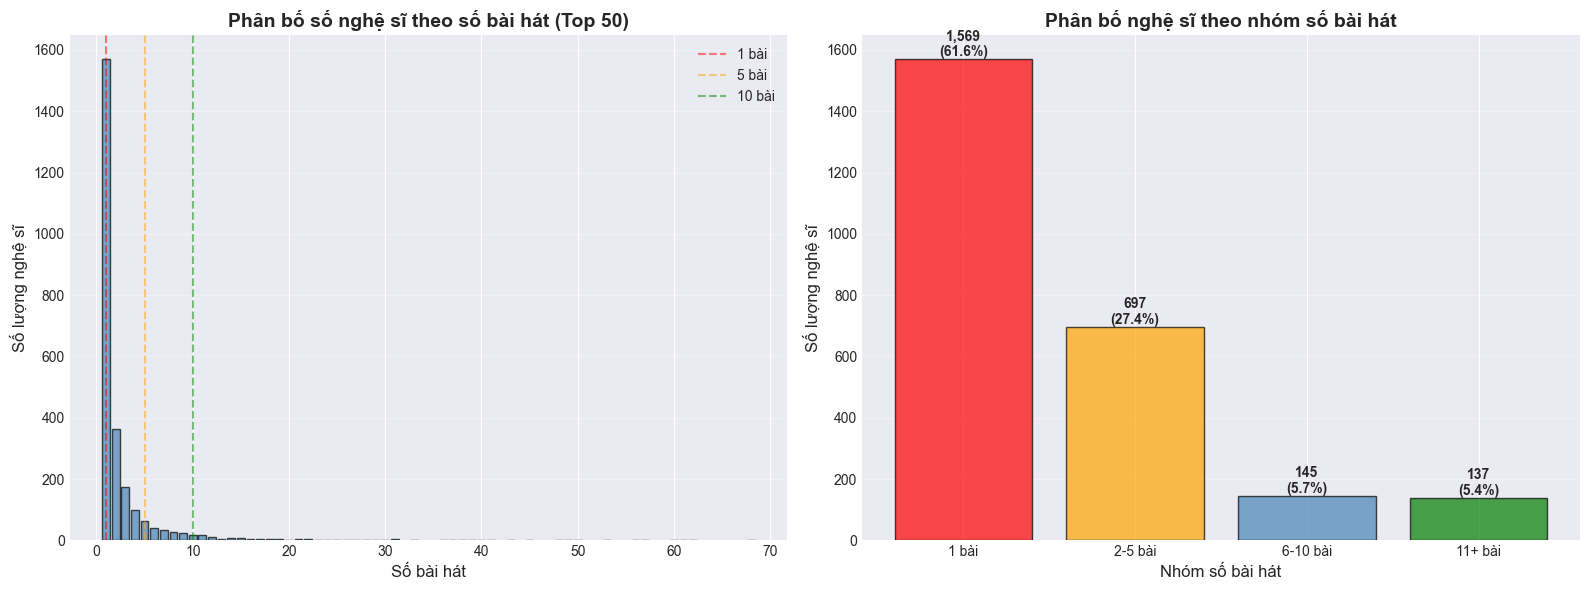

In [111]:
# Phân tích phân bố: Có bao nhiêu nghệ sĩ có 1 bài, 2 bài, 3 bài, ...
import matplotlib.pyplot as plt

track_count_distribution = artist_stats['track_count'].value_counts().sort_index()

print("=" * 80)
print("PHÂN BỐ SỐ LƯỢNG BÀI HÁT THEO NGHỆ SĨ")
print("=" * 80)
print(f"Tổng số nghệ sĩ: {len(artist_stats):,}")
print()
print("Top 20 giá trị phổ biến nhất:")
print(f"Số bài | Số nghệ sĩ | Tỷ lệ")
print("-" * 40)
for count, num_artists in track_count_distribution.head(20).items():
    pct = (num_artists / len(artist_stats)) * 100
    print(f"  {count:3.0f}  | {num_artists:6,} | {pct:5.1f}%")
print()

# Thống kê tổng hợp
artists_1_song = (artist_stats['track_count'] == 1).sum()
artists_2_5_songs = ((artist_stats['track_count'] >= 2) & (artist_stats['track_count'] <= 5)).sum()
artists_6_10_songs = ((artist_stats['track_count'] >= 6) & (artist_stats['track_count'] <= 10)).sum()
artists_11_plus = (artist_stats['track_count'] > 10).sum()

print(f"Nghệ sĩ có 1 bài:        {artists_1_song:6,} ({artists_1_song/len(artist_stats)*100:5.1f}%)")
print(f"Nghệ sĩ có 2-5 bài:      {artists_2_5_songs:6,} ({artists_2_5_songs/len(artist_stats)*100:5.1f}%)")
print(f"Nghệ sĩ có 6-10 bài:     {artists_6_10_songs:6,} ({artists_6_10_songs/len(artist_stats)*100:5.1f}%)")
print(f"Nghệ sĩ có trên 10 bài:  {artists_11_plus:6,} ({artists_11_plus/len(artist_stats)*100:5.1f}%)")
print()
print("=" * 80)
print()

# Vẽ bar plot phân bố
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Phân bố đầy đủ (giới hạn top 50 để nhìn rõ)
top_50 = track_count_distribution.head(50)
axes[0].bar(top_50.index, top_50.values, color='steelblue', alpha=0.7, edgecolor='black')
axes[0].set_xlabel('Số bài hát', fontsize=12)
axes[0].set_ylabel('Số lượng nghệ sĩ', fontsize=12)
axes[0].set_title('Phân bố số nghệ sĩ theo số bài hát (Top 50)', fontsize=14, fontweight='bold')
axes[0].grid(alpha=0.3, axis='y')

# Highlight một số mốc quan trọng
axes[0].axvline(x=1, color='red', linestyle='--', alpha=0.5, label='1 bài')
axes[0].axvline(x=5, color='orange', linestyle='--', alpha=0.5, label='5 bài')
axes[0].axvline(x=10, color='green', linestyle='--', alpha=0.5, label='10 bài')
axes[0].legend()

# Plot 2: Phân bố theo nhóm (aggregated)
groups = ['1 bài', '2-5 bài', '6-10 bài', '11+ bài']
counts = [artists_1_song, artists_2_5_songs, artists_6_10_songs, artists_11_plus]

bars = axes[1].bar(groups, counts, color=['red', 'orange', 'steelblue', 'green'], alpha=0.7, edgecolor='black')
axes[1].set_xlabel('Nhóm số bài hát', fontsize=12)
axes[1].set_ylabel('Số lượng nghệ sĩ', fontsize=12)
axes[1].set_title('Phân bố nghệ sĩ theo nhóm số bài hát', fontsize=14, fontweight='bold')
axes[1].grid(alpha=0.3, axis='y')

# Thêm label lên cột
for bar, count in zip(bars, counts):
    height = bar.get_height()
    pct = (count / len(artist_stats)) * 100
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                f'{count:,}\n({pct:.1f}%)',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

### Bước 3: Phân loại nghệ sĩ theo chiến lược sản xuất (TOÀN BỘ DỮ LIỆU)

In [113]:
# SỬ DỤNG TOÀN BỘ DỮ LIỆU - KHÔNG LỌC THEO SỐ BÀI HÁT
# Lý do: Muốn phân tích THỰC SỰ các chiến lược low output (1-2 bài) vs high output

print("=" * 80)
print("PHÂN LOẠI NGHỆ SĨ THEO CHIẾN LƯỢC - TOÀN BỘ DỮ LIỆU")
print("=" * 80)
print(f"Số nghệ sĩ phân tích: {len(artist_stats):,}")
print()

# Tính percentiles trên TOÀN BỘ dữ liệu
q75 = artist_stats['track_count'].quantile(0.75)
q90 = artist_stats['track_count'].quantile(0.90)
q95 = artist_stats['track_count'].quantile(0.95)

print("PHÂN LOẠI NGHỆ SĨ THEO SỐ LƯỢNG BÀI HÁT")
print("=" * 80)
print(f"Q75 (75%): {q75:.0f} bài")
print(f"Q90 (90%): {q90:.0f} bài")
print(f"Q95 (95%): {q95:.0f} bài")
print(f"Max:       {artist_stats['track_count'].max():.0f} bài")
print()

def classify_strategy(count):
    if count <= q75:
        return 'Low Output'
    elif count <= q95:
        return 'Medium Output'
    else:
        return 'High Output'

# Phân loại cho TOÀN BỘ DỮ LIỆU
artist_stats['strategy'] = artist_stats['track_count'].apply(classify_strategy)

# Thống kê theo nhóm
strategy_summary = artist_stats.groupby('strategy').agg({
    'artist_name': 'count',
    'track_count': ['mean', 'median', 'min', 'max'],
    'artist_popularity': ['mean', 'median', 'std'],
    'artist_followers': ['mean', 'median']
})

print("Phân bố nghệ sĩ theo chiến lược:")
print(artist_stats['strategy'].value_counts().sort_index())
print()
print("=" * 80)
print("THỐNG KÊ THEO CHIẾN LƯỢC SẢN XUẤT")
print("=" * 80)
print()

for strategy in ['Low Output', 'Medium Output', 'High Output']:
    subset = artist_stats[artist_stats['strategy'] == strategy]
    if len(subset) > 0:
        print(f"{strategy}:")
        print(f"  Số nghệ sĩ: {len(subset):,}")
        print(f"  Số bài hát trung bình: {subset['track_count'].mean():.1f}")
        print(f"  Artist popularity trung bình: {subset['artist_popularity'].mean():.2f}")
        print(f"  Artist followers trung bình: {subset['artist_followers'].mean():,.0f}")
        print()

print("=" * 80)

PHÂN LOẠI NGHỆ SĨ THEO CHIẾN LƯỢC - TOÀN BỘ DỮ LIỆU
Số nghệ sĩ phân tích: 2,548

PHÂN LOẠI NGHỆ SĨ THEO SỐ LƯỢNG BÀI HÁT
Q75 (75%): 2 bài
Q90 (90%): 6 bài
Q95 (95%): 11 bài
Max:       331 bài

Phân bố nghệ sĩ theo chiến lược:
strategy
High Output       119
Low Output       1931
Medium Output     498
Name: count, dtype: int64

THỐNG KÊ THEO CHIẾN LƯỢC SẢN XUẤT

Low Output:
  Số nghệ sĩ: 1,931
  Số bài hát trung bình: 1.2
  Artist popularity trung bình: 48.99
  Artist followers trung bình: 1,219,174

Medium Output:
  Số nghệ sĩ: 498
  Số bài hát trung bình: 5.1
  Artist popularity trung bình: 66.11
  Artist followers trung bình: 5,685,405

High Output:
  Số nghệ sĩ: 119
  Số bài hát trung bình: 33.2
  Artist popularity trung bình: 77.28
  Artist followers trung bình: 27,097,135



### Bước 4: Trực quan hóa so sánh các chiến lược

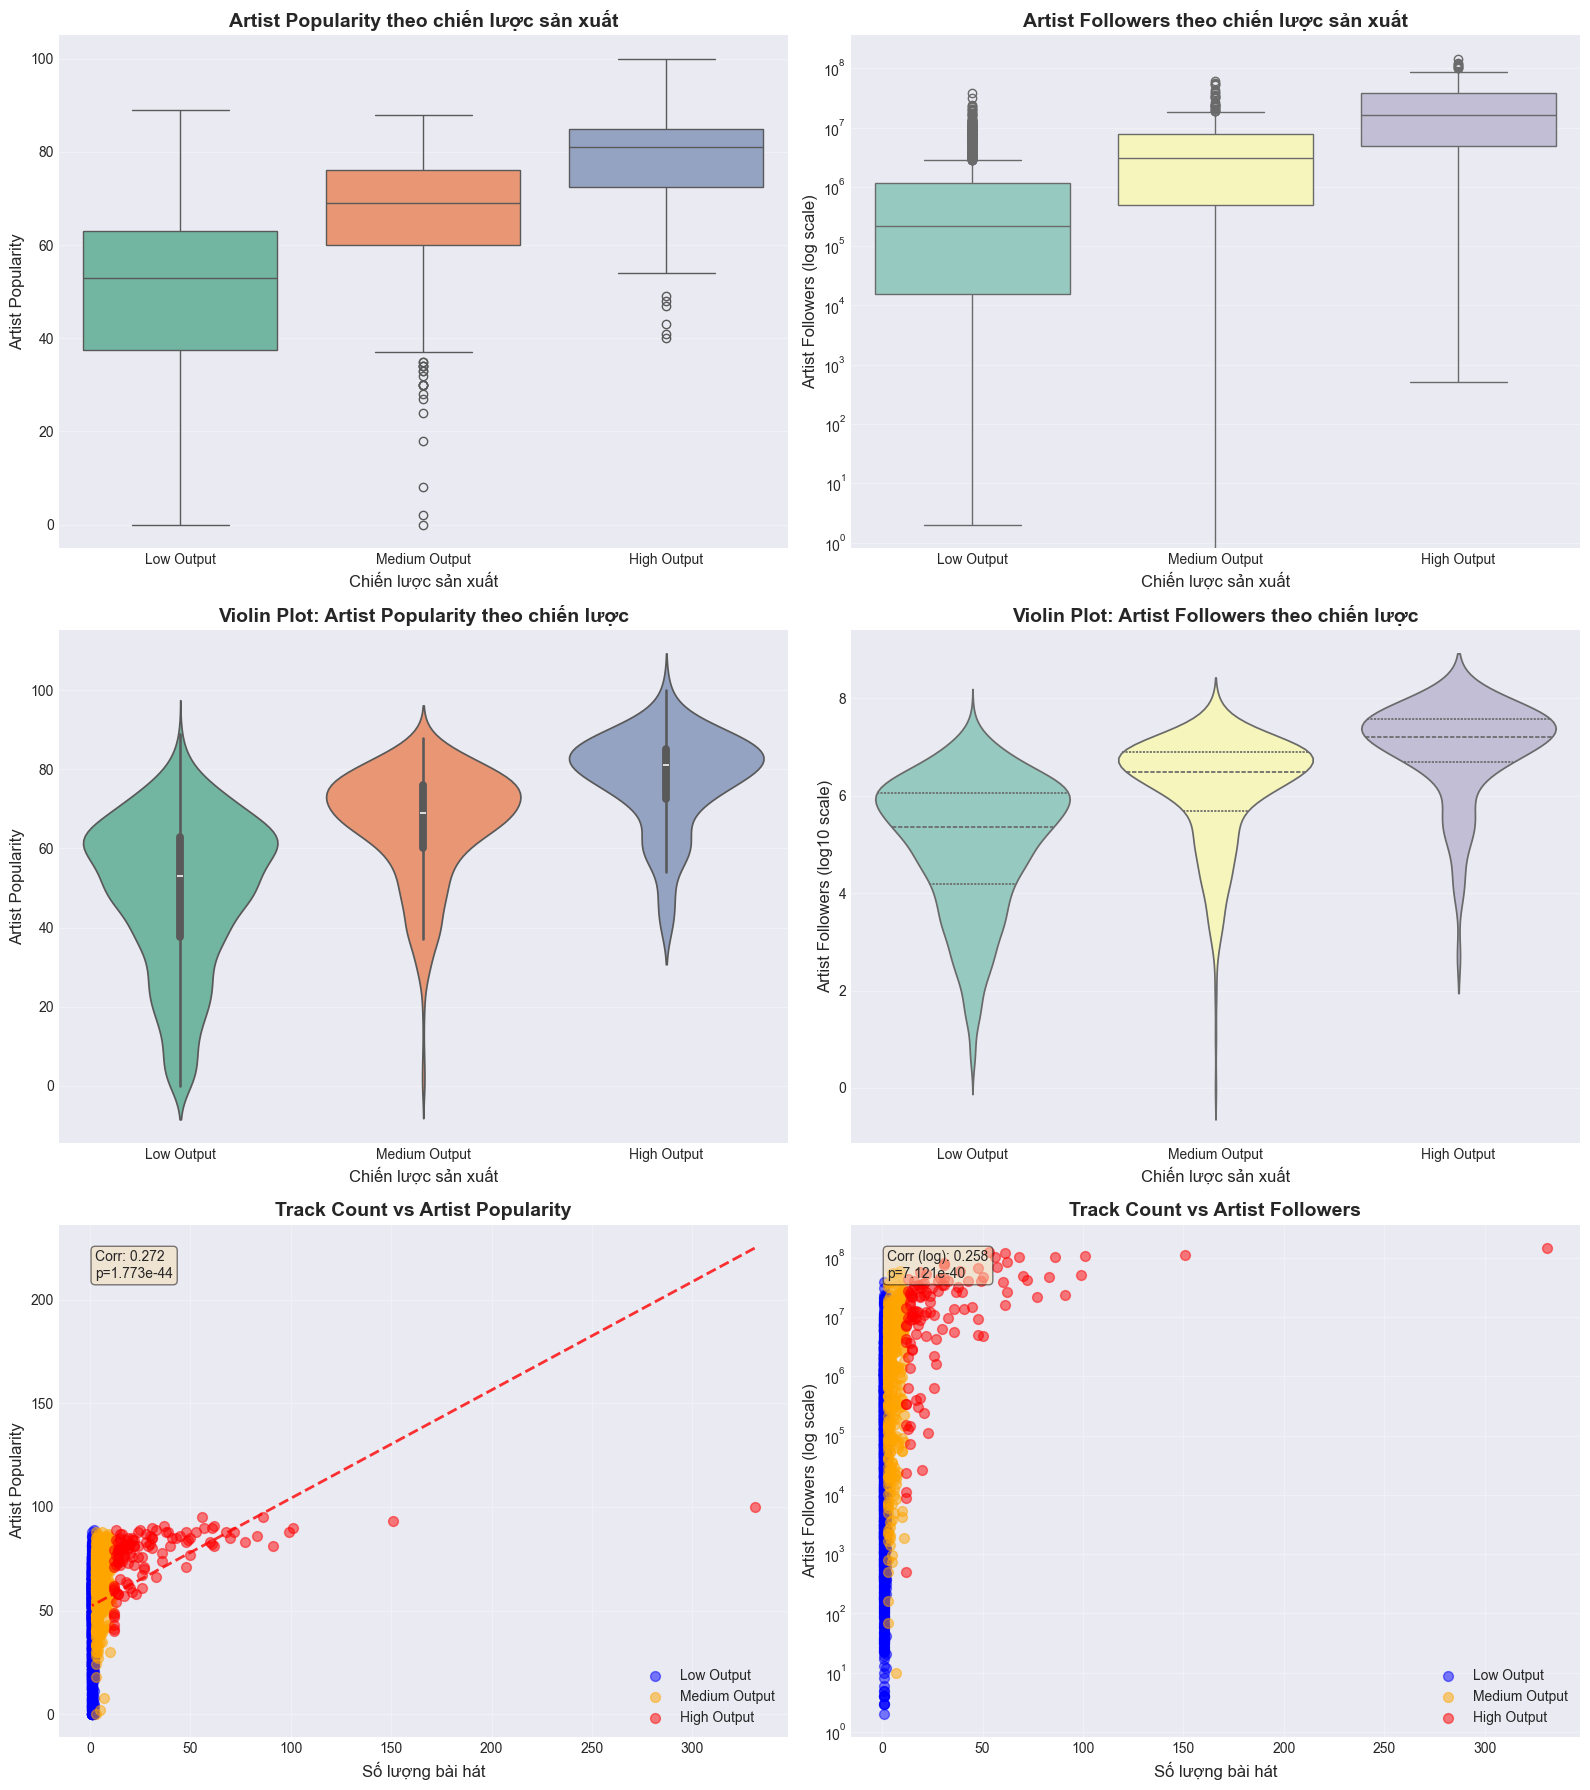

PHÂN TÍCH TƯƠNG QUAN
Track Count vs Artist Popularity: r = 0.2721, p = 1.7725e-44
Track Count vs Artist Followers (log): r = 0.2575, p = 7.1210e-40

Artist popularity có tương quan MẠNH HƠN với số lượng bài hát


In [115]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

fig, axes = plt.subplots(3, 2, figsize=(16, 18))

# 1. Box plot: Artist popularity theo strategy
strategy_order = ['Low Output', 'Medium Output', 'High Output']
sns.boxplot(data=artist_stats, x='strategy', y='artist_popularity', order=strategy_order, 
            palette='Set2', ax=axes[0, 0])
axes[0, 0].set_title('Artist Popularity theo chiến lược sản xuất', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Chiến lược sản xuất', fontsize=12)
axes[0, 0].set_ylabel('Artist Popularity', fontsize=12)
axes[0, 0].grid(alpha=0.3, axis='y')

# 2. Box plot: Artist followers theo strategy
sns.boxplot(data=artist_stats, x='strategy', y='artist_followers', order=strategy_order,
            palette='Set3', ax=axes[0, 1])
axes[0, 1].set_title('Artist Followers theo chiến lược sản xuất', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Chiến lược sản xuất', fontsize=12)
axes[0, 1].set_ylabel('Artist Followers (log scale)', fontsize=12)
axes[0, 1].set_yscale('log')
axes[0, 1].grid(alpha=0.3, axis='y')

# 3. Violin plot: Artist popularity theo strategy
sns.violinplot(data=artist_stats, x='strategy', y='artist_popularity', order=strategy_order,
               palette='Set2', ax=axes[1, 0])
axes[1, 0].set_title('Violin Plot: Artist Popularity theo chiến lược', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Chiến lược sản xuất', fontsize=12)
axes[1, 0].set_ylabel('Artist Popularity', fontsize=12)
axes[1, 0].grid(alpha=0.3, axis='y')

# 4. Violin plot: Artist followers theo strategy (log transformed)
# Tạo cột log followers để vẽ violin plot đẹp hơn
artist_stats['log_followers'] = np.log10(artist_stats['artist_followers'] + 1)

sns.violinplot(data=artist_stats, x='strategy', y='log_followers', order=strategy_order,
               palette='Set3', ax=axes[1, 1], inner='quartile')
axes[1, 1].set_title('Violin Plot: Artist Followers theo chiến lược', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Chiến lược sản xuất', fontsize=12)
axes[1, 1].set_ylabel('Artist Followers (log10 scale)', fontsize=12)
axes[1, 1].grid(alpha=0.3, axis='y')

# 5. Scatter plot: Track count vs Artist popularity
colors = {'Low Output': 'blue', 'Medium Output': 'orange', 'High Output': 'red'}
for strategy in strategy_order:
    subset = artist_stats[artist_stats['strategy'] == strategy]
    axes[2, 0].scatter(subset['track_count'], subset['artist_popularity'], 
                      alpha=0.5, label=strategy, c=colors[strategy], s=50)

axes[2, 0].set_xlabel('Số lượng bài hát', fontsize=12)
axes[2, 0].set_ylabel('Artist Popularity', fontsize=12)
axes[2, 0].set_title('Track Count vs Artist Popularity', fontsize=14, fontweight='bold')
axes[2, 0].legend()
axes[2, 0].grid(alpha=0.3)

# Thêm trendline cho Artist Popularity
from scipy.stats import pearsonr
x = artist_stats['track_count']
y_artist = artist_stats['artist_popularity']
z_artist = np.polyfit(x, y_artist, 1)
p_artist = np.poly1d(z_artist)
axes[2, 0].plot(x, p_artist(x), "r--", alpha=0.8, linewidth=2)

corr_artist, p_val_artist = pearsonr(x, y_artist)
axes[2, 0].text(0.05, 0.95, f'Corr: {corr_artist:.3f}\np={p_val_artist:.3e}', 
               transform=axes[2, 0].transAxes, fontsize=10, verticalalignment='top',
               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# 6. Scatter plot: Track count vs Artist followers
for strategy in strategy_order:
    subset = artist_stats[artist_stats['strategy'] == strategy]
    axes[2, 1].scatter(subset['track_count'], subset['artist_followers'], 
                      alpha=0.5, label=strategy, c=colors[strategy], s=50)

axes[2, 1].set_xlabel('Số lượng bài hát', fontsize=12)
axes[2, 1].set_ylabel('Artist Followers (log scale)', fontsize=12)
axes[2, 1].set_title('Track Count vs Artist Followers', fontsize=14, fontweight='bold')
axes[2, 1].set_yscale('log')  # Log scale cho followers
axes[2, 1].legend()
axes[2, 1].grid(alpha=0.3)

# Tính correlation cho followers (sử dụng log)
y_followers = np.log10(artist_stats['artist_followers'] + 1)  # +1 để tránh log(0)
corr_followers, p_val_followers = pearsonr(x, y_followers)
axes[2, 1].text(0.05, 0.95, f'Corr (log): {corr_followers:.3f}\np={p_val_followers:.3e}', 
               transform=axes[2, 1].transAxes, fontsize=10, verticalalignment='top',
               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

# In kết quả correlation
print("=" * 80)
print("PHÂN TÍCH TƯƠNG QUAN")
print("=" * 80)
print(f"Track Count vs Artist Popularity: r = {corr_artist:.4f}, p = {p_val_artist:.4e}")
print(f"Track Count vs Artist Followers (log): r = {corr_followers:.4f}, p = {p_val_followers:.4e}")
print()
if abs(corr_artist) > abs(corr_followers):
    print("Artist popularity có tương quan MẠNH HƠN với số lượng bài hát")
else:
    print("Artist followers có tương quan MẠNH HƠN với số lượng bài hát")
print("=" * 80)

## PHÂN TÍCH CHIẾN LƯỢC SẢN XUẤT CỦA NGHỆ SĨ

### 1. Artist Popularity - Mức độ nổi tiếng

Kết quả từ box plot, violin plot và phân tích thống kê cho thấy sự khác biệt rõ rệt giữa các chiến lược sản xuất:

**Low Output:**
- Artist popularity trung bình thấp nhất, phản ánh độ nổi tiếng hạn chế
- Độ biến động lớn với phân bố rộng, cho thấy kết quả không ổn định
- Từ violin plot, phần lớn nghệ sĩ tập trung ở mức thấp đến trung bình
- Rủi ro cao: Khó dự đoán thành công, phụ thuộc nhiều vào yếu tố may mắn

**Medium Output:**
- Artist popularity cải thiện đáng kể so với Low Output
- Phân bố đồng đều hơn, kết quả đáng tin cậy hơn
- Ít outliers hơn, cho thấy tính ổn định tốt hơn
- Chiến lược cân bằng giữa số lượng và chất lượng

**High Output:**
- Artist popularity cao nhất và ổn định nhất
- Violin plot hẹp hơn, tập trung mạnh, cho thấy tính nhất quán cao
- Tuy có một số outliers thấp, nhưng đa số đạt mức tốt
- Chiến lược bền vững và đáng tin cậy

---

### 2. Artist Followers - Quy mô fanbase

**Low Output:**
- Số followers trung bình thấp nhất
- Phân bố rải rác trên log scale, thiếu tính nhất quán
- Rất ít nghệ sĩ có fanbase lớn, khó xây dựng cộng đồng

**Medium Output:**
- Followers tăng đáng kể so với Low Output
- Phân bố tập trung hơn trên log scale, cho thấy khả năng xây dựng fanbase tốt hơn
- Chiến lược hiệu quả để phát triển cộng đồng người hâm mộ

**High Output:**
- Followers đạt mức cao nhất với phân bố tập trung
- Violin plot trên log scale cho thấy đa số nghệ sĩ có fanbase vững chắc
- Mặc dù có một số outliers, nhưng xu hướng chung là fanbase lớn
- Bằng chứng rõ ràng: càng ra nhiều bài, càng dễ thu hút và giữ chân người hâm mộ

---

### 3. Phân tích tương quan

**Tương quan với Artist Popularity:**
- Hệ số tương quan dương, cho thấy xu hướng tăng nhẹ
- Giải thích: Độ biến động lớn ở nhóm Low Output làm suy yếu mối tương quan tổng thể
- Nhiều nghệ sĩ ít bài có popularity dao động mạnh

**Tương quan với Artist Followers:**
- Hệ số tương quan với log followers cho thấy mối liên hệ rõ ràng hơn
- Xu hướng: Nghệ sĩ phát hành nhiều bài hát có xu hướng có fanbase lớn hơn
- Insight quan trọng: Số lượng bài hát ảnh hưởng đến khả năng xây dựng cộng đồng người hâm mộ

---

### 4. Kết luận

**So sánh các chiến lược:**

Low Output: Artist popularity thấp, followers hạn chế. Độ ổn định rất thấp, khả năng dự đoán khó, rủi ro cao.

Medium Output: Artist popularity trung bình, followers tăng đáng kể. Độ ổn định trung bình, khả năng dự đoán khá, rủi ro vừa phải.

High Output: Artist popularity cao nhất, followers lớn nhất. Độ ổn định rất cao, dễ dự đoán, rủi ro thấp.

**Kết luận chính:**

1. Nghệ sĩ phát hành nhiều bài hát không chỉ đạt artist popularity cao hơn mà còn xây dựng được fanbase lớn hơn đáng kể.

2. Chiến lược Low Output mang tính rủi ro cao, phụ thuộc vào may mắn, khó dự đoán và dễ thất bại trong việc xây dựng sự nghiệp bền vững.

3. Chiến lược High Output thể hiện tính bền vững: ổn định về popularity, fanbase vững chắc, rủi ro thấp.

4. Chiến lược Medium Output là điểm cân bằng tốt cho nghệ sĩ mới hoặc chưa có nguồn lực lớn.

**Khuyến nghị:** Nghệ sĩ nên hướng tới chiến lược High Output để tối đa hóa cơ hội thành công và xây dựng fanbase bền vững. Phát hành nhiều bài hát giúp tăng độ hiện diện, học hỏi từ phản hồi của khán giả, và duy trì sự quan tâm của người hâm mộ.